# TravelTide Mastery Project

## Segmentbasierte Rewards- und Perk-Empfehlungen

### Ziel dieses Notebooks

Im vorherigen Notebook wurden 5.752 Kunden mithilfe eines hybriden Ansatzes in zwölf Segmente unterteilt. Kunden mit besonders deutlich ausgeprägten Verhaltensmerkmalen wurden regelbasiert segmentiert. Für die übrigen Kunden wurden mithilfe von K-Means zusätzliche Verhaltensgruppen gebildet.

Ziel dieses Notebooks ist es, für die zwölf Kundensegmente geeignete Rewards-Benefits abzuleiten und segmentbezogene Marketingempfehlungen zu entwickeln.

Das Notebook gliedert sich daher in folgende Arbeitsschritte:

1. die finale segmentierte Kundentabelle einlesen und kontrollieren,
2. Größe und Verteilung der zwölf finalen Kundensegmente betrachten,
3. einen finalen Katalog mit neun geeigneten Perk-Familien definieren,
4. die Kundenbedürfnisse in segmentbasierte Perk-Entscheidungen übersetzen,
5. die primären und alternativen Perks konkret ausgestalten und den Kunden zuordnen,
6. die resultierende Perk-Verteilung auswerten und kontrollieren,
7. segmentspezifische Kommunikationsansätze entwickeln,
8. ein Konzept zur experimentellen Überprüfung der Empfehlungen erstellen,
9. die zentralen Ergebnisse und Handlungsempfehlungen zusammenfassen,
10. die finale Kundentabelle und die strategischen Übersichten exportieren.

Neben den ursprünglich von Elena, Head of Marketing, vorgeschlagenen Benefits werden weitere Vorteile definiert, die sie sich nachvollziehbar aus dem beobachteten Kundenverhalten ableiten lassen.

Die Empfehlungen beruhen auf historischen Verhaltensdaten und stellen keine kausalen Wirkungsnachweise dar. Ihre tatsächliche Wirksamkeit sollte daher nach Einführung des Rewards-Programms durch A/B-Tests oder Pilotkampagnen überprüft werden.

## 1. Datenimport und erste Kontrolle

Als Datengrundlage wird die im vorherigen Notebook exportierte Kundentabelle verwendet. Sie enthält alle aufbereiteten Kundenmerkmale sowie das finale Kundensegment und die verwendete Segmentierungsmethode.

Nach dem Import wird geprüft, ob alle 5.752 Kunden enthalten sind, jeder Nutzer eindeutig vorkommt und keine finale Segmentzuordnung fehlt.

In [2]:
# Bibliotheken importieren.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")

In [3]:
# Datei einlesen.

data_path = Path(
    "../data/finalized/traveltide_customer_segments.csv"
)

customers = pd.read_csv(data_path)

print("Geladene Datei:", data_path.resolve())
print("Form der Tabelle:", customers.shape)

Geladene Datei: C:\Users\noraa\Desktop\Materialien\11 Mastery Project\traveltide-mastery-project\data\finalized\traveltide_customer_segments.csv
Form der Tabelle: (5752, 94)


In [4]:
# Grundlegende Datenprüfung.

print(
    "Zeilen:",
    len(customers)
)

print(
    "Eindeutige Nutzer:",
    customers["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    customers["user_id"].duplicated().sum()
)

print(
    "Fehlende finale Segmente:",
    customers["final_segment"].isna().sum()
)

print(
    "Anzahl finaler Segmente:",
    customers["final_segment"].nunique()
)

Zeilen: 5752
Eindeutige Nutzer: 5752
Doppelte Nutzer: 0
Fehlende finale Segmente: 0
Anzahl finaler Segmente: 12


In [5]:
# Vorschau und Spaltenübersicht.

display(customers.head())

print("Anzahl der Spalten:", customers.shape[1])
print("\nSpalten:")

print(customers.columns.tolist())

,user_id,final_segment,segmentation_method,rule_based_segment,kmeans_cluster,kmeans_segment,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age,customer_tenure_days,customer_tenure_months,session_count,mean_session_duration_minutes,median_session_duration_minutes,total_page_clicks,mean_page_clicks,low_click_session_rate,booking_session_count,flight_booking_session_count,hotel_booking_session_count,package_booking_session_count,cancellation_count,flight_discount_offer_count,hotel_discount_offer_count,mean_flight_discount_amount,mean_hotel_discount_amount,discounted_flight_booking_count,discounted_hotel_booking_count,booking_session_rate,cancellation_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,flight_booking_count,total_flight_value_before_discount_usd,total_flight_value_after_discount_usd,total_realized_flight_spend_usd,mean_flight_booking_value_after_discount_usd,total_seats,mean_seats,total_checked_bags,mean_checked_bags,mean_fare_per_seat_after_discount_usd,return_flight_rate,cancelled_flight_count,weighted_fare_per_seat_after_discount_usd,hotel_booking_count,total_hotel_value_before_discount_usd,mean_hotel_value_before_discount_usd,total_hotel_value_after_discount_usd,mean_hotel_value_after_discount_usd,total_realized_hotel_spend_usd,mean_completed_hotel_spend_usd,total_hotel_nights,mean_hotel_nights,total_rooms,mean_rooms,mean_hotel_price_per_room_usd,median_hotel_price_per_room_usd,unique_hotel_brands,unique_hotel_cities,extended_stay_booking_count,extended_stay_booking_share,cancelled_hotel_count,preferred_hotel_segment,preferred_hotel_city,hotel_price_tier_share_Low price,hotel_price_tier_share_Medium price,hotel_price_tier_share_High price,hotel_price_tier_share_Very high price,has_flight_booking,has_hotel_booking,has_travel_booking,checked_bags_per_seat,total_cancelled_bookings,historical_customer_value_usd,total_discount_offer_count,total_discounted_booking_count,booking_discount_rate,high_value_booker,family_traveler,long_stay_hotel_guest,discount_responsive_traveler,baggage_intensive_flyer,cancellation_experienced_traveler,matched_rule_count
0,23557,Long-Stay Hotel Guests,Rule-based,Long-Stay Hotel Guests,NaN,NaN,1958-12-08,F,True,False,usa,new york,LGA,40.777,-73.872,2021-07-22,64,736,24.179,8,1.277,1.158,82,10.250,0.000,2,0,2,0,0,0,2,NaN,0.175,0,1,0.250,0.000,0.000,NaN,0.500,0.000,0.000,0.000,0.000,NaN,0.000,NaN,0.000,NaN,NaN,NaN,0.000,NaN,2.000,3802.000,1901.000,3670.500,1835.250,3670.500,1835.250,20.000,10.000,3.000,1.500,177.000,177.000,2.000,2.000,1.000,0.500,0.000,Economy,Calgary,0.500,0.000,0.000,0.500,False,True,True,0.000,0.000,3670.500,2,1,0.500,False,False,True,True,False,False,2
1,94883,Multi-Person Travelers,K-Means,Unassigned,3.000,Multi-Person Travelers,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,51,536,17.608,8,1.129,0.625,73,9.125,0.000,2,2,2,2,0,0,1,NaN,0.100,0,0,0.250,0.000,1.000,NaN,0.000,2.000,864.090,864.090,864.090,432.045,3.000,1.500,1.000,0.500,276.252,1.000,0.000,288.030,2.000,230.000,115.000,230.000,115.000,230.000,115.000,2.000,1.000,3.000,1.500,90.000,90.000,2.000,2.000,0.000,0.000,0.000,Luxury,Jacksonville,0.500,0.500,0.000,0.000,True,True,True,0.333,0.000,1094.090,1,0,0.000,False,False,False,False,False,False,0
2,101486,Active Longer-Stay Hotel Guests,K-Means,Unassigned,4.000,Active Longer-Stay Hotel Guests,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,50,526,17.280,8,2.038,2.433,131,16.375,0.000,2,1,2,1,0,2,0,0.075,NaN,0,0,0.250,0.000,0.500,0.000,NaN,1.000,189.910,189.910,189.910,189.910,1.000,1.000,0.000,0.000,189.910,1.000,0.000,189.910,2.000,2199.000,1099.500,2199.000,1099.500,2199.000,1099.500,8.000,4.000,3.000,1.500,198.500,198.500,2.000,2.000,0.000,0.000,0.000,Luxury,Edmonton,0.000,0.500,0.000,0.500,True,True,True,0.000,0.000,2388.910,2,0,0.000,False,False,False,False,False,False,0
3,101961,Active Longer-Stay

Anzahl der Spalten: 94

Spalten:
['user_id', 'final_segment', 'segmentation_method', 'rule_based_segment', 'kmeans_cluster', 'kmeans_segment', 'birthdate', 'gender', 'married', 'has_children', 'home_country', 'home_city', 'home_airport', 'home_airport_lat', 'home_airport_lon', 'sign_up_date', 'age', 'customer_tenure_days', 'customer_tenure_months', 'session_count', 'mean_session_duration_minutes', 'median_session_duration_minutes', 'total_page_clicks', 'mean_page_clicks', 'low_click_session_rate', 'booking_session_count', 'flight_booking_session_count', 'hotel_booking_session_count', 'package_booking_session_count', 'cancellation_count', 'flight_discount_offer_count', 'hotel_discount_offer_count', 'mean_flight_discount_amount', 'mean_hotel_discount_amount', 'discounted_flight_booking_count', 'discounted_hotel_booking_count', 'booking_session_rate', 'cancellation_session_rate', 'package_booking_rate', 'flight_discount_conversion_rate', 'hotel_discount_conversion_rate', 'flight_booking_c

## 2. Überblick über die finalen Segmente

Zunächst werden Größe und Anteil der zwölf finalen Kundensegmente betrachtet. Dadurch lässt sich einschätzen, wie viele Kunden mit den jeweiligen Rewards- und Kommunikationsmaßnahmen erreicht werden können.

Die Segmentgröße wird bei der späteren Perk-Auswahl mitberücksichtigt. Sie entscheidet jedoch nicht allein über die Relevanz eines Segments, da auch kleinere Gruppen einen hohen Kundenwert oder besonders klar erkennbare Bedürfnisse besitzen können.

In [6]:
# Segmentgrößen berechnen.

segment_overview = (
    customers
    .groupby(
        [
            "segmentation_method",
            "final_segment"
        ]
    )
    .size()
    .rename("customer_count")
    .reset_index()
)


segment_overview["customer_share"] = (
    segment_overview["customer_count"]
    / len(customers)
)


segment_overview["customer_share_percent"] = (
    segment_overview["customer_share"] * 100
)


segment_overview = (
    segment_overview
    .sort_values(
        "customer_count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(segment_overview)

,segmentation_method,final_segment,customer_count,customer_share,customer_share_percent
0,K-Means,Premium Short-Stay Package Travelers,987,0.172,17.159
1,Rule-based,Discount-Responsive Travelers,868,0.151,15.090
2,Rule-based,Baggage-Intensive Flyers,789,0.137,13.717
3,K-Means,Active Longer-Stay Hotel Guests,647,0.112,11.248
4,K-Means,Low-Conversion Browsers,583,0.101,10.136
5,Rule-based,Long-Stay Hotel Guests,558,0.097,9.701
6,Rule-based,Cancellation-Experienced Travelers,330,0.057,5.737
7,K-Means,Multi-Person Travelers,282,0.049,4.903
8,Rule-based,High-Value Bookers,208,0.036,3.616
9,Rule-based,Family Travelers,182,0.032,3.164


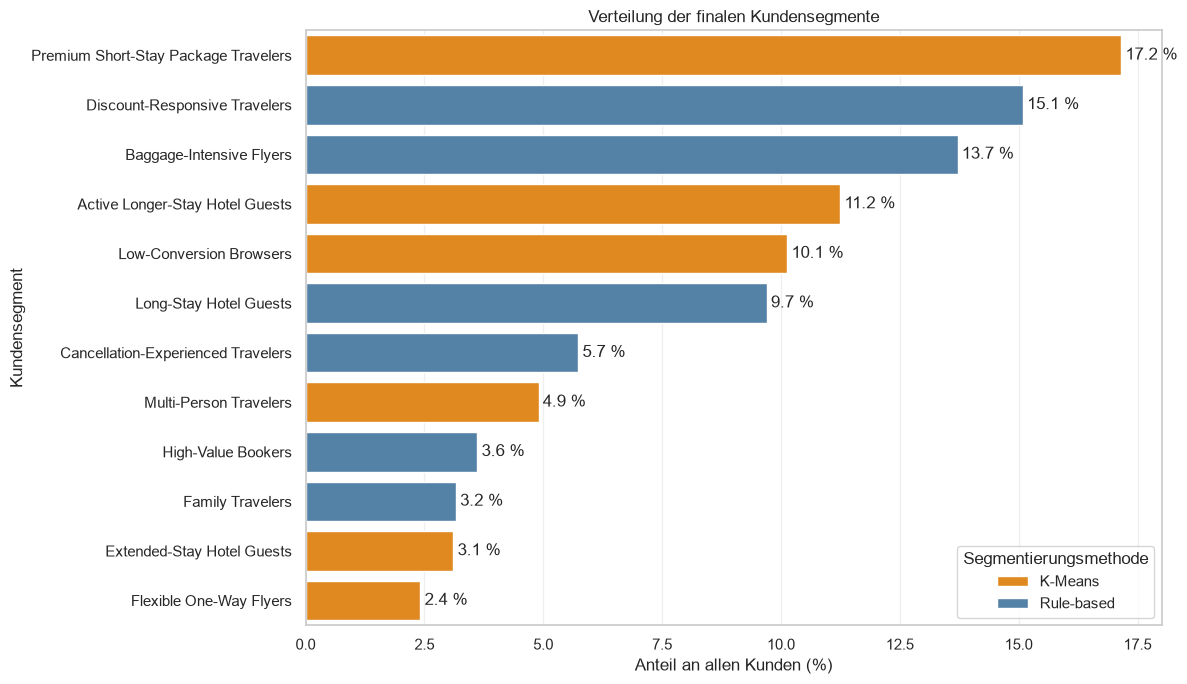

In [7]:
# Segmentgrößen visualisieren.
 
plt.figure(figsize=(12, 7))

segment_plot = sns.barplot(
    data=segment_overview,
    y="final_segment",
    x="customer_share_percent",
    hue="segmentation_method",
    dodge=False,
    palette={
        "Rule-based": "steelblue",
        "K-Means": "darkorange"
    }
)


for container in segment_plot.containers:
    segment_plot.bar_label(
        container,
        fmt="%.1f %%",
        padding=3
    )


plt.title("Verteilung der finalen Kundensegmente")
plt.xlabel("Anteil an allen Kunden (%)")
plt.ylabel("Kundensegment")
plt.legend(title="Segmentierungsmethode")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Vollständigkeit der Segmentübersicht prüfen.

print(
    "Kunden in der Segmentübersicht:",
    segment_overview["customer_count"].sum()
)

print(
    "Summe der Segmentanteile:",
    round(
        segment_overview["customer_share"].sum(),
        3
    )
)

Kunden in der Segmentübersicht: 5752
Summe der Segmentanteile: 1.0


## 3. Finaler Perk-Katalog

Bevor den Kundensegmenten konkrete Rewards-Benefits zugeordnet werden, wird ein einheitlicher und operativ überschaubarer Perk-Katalog definiert.

Als Ausgangspunkt nennt Elena, Head of Marketing, fünf mögliche Vorteile: eine kostenlose Hotelmahlzeit, kostenloses Aufgabegepäck, keine
Stornierungsgebühren, exklusive Rabatte und eine kostenlose Hotelnacht bei gemeinsamer Flug- und Hotelbuchung.

Diese Vorschläge wurden anhand der identifizierten Kundensegmente überprüft und weiterentwickelt. Dabei zeigte sich, dass einige der ursprünglichen Benefits nur eingeschränkt zu den beobachteten Bedürfnissen passen. Eine kostenlose Hotelmahlzeit ist beispielsweise nicht in jeder Unterkunft verfügbar und könnte insbesondere bei Extended-Stay-Unterkünften mit Apartmentcharakter wenig relevant sein. Eine kostenlose Hotelnacht, die ausschließlich an eine Paketbuchung gebunden ist, ist ebenfalls nicht für alle Hotelkundengruppen geeignet.

Statt die ursprünglichen Vorschläge unverändert zu übernehmen, werden sie deshalb in neun flexibler einsetzbare Perk-Familien überführt. Diese bilden unterschiedliche Grundbedürfnisse wie Preisvorteile, Flexibilität, Reisekomfort, Unterstützung bei gemeinsamen Reisen und Mehrwert bei längeren Aufenthalten ab.

| Perk-Familie | Adressiertes Kundenbedürfnis | Mögliche Ausgestaltung |
|---|---|---|
| **Family Travel Credit** | Finanzielle Entlastung bei Familienreisen | Guthaben für Familienzimmer, Sitzplatzreservierungen oder zusätzliches Gepäck |
| **Group Booking Credit** | Kostenersparnis bei Reisen mit mehreren Personen | Reiseguthaben ab einer definierten Anzahl gemeinsam Reisender |
| **Free Additional Checked Bag** | Mehr Gepäckkomfort und geringere Zusatzkosten | Ein zusätzliches kostenloses Aufgabegepäckstück |
| **Complimentary Flight Rebooking** | Flexibilität bei geänderten Flugplänen | Eine gebührenfreie Änderung von Reisedatum oder Flugstrecke |
| **Flexible Cancellation Protection** | Planungssicherheit und geringeres finanzielles Risiko | Eine kostenfreie Stornierung innerhalb festgelegter Bedingungen |
| **Personalized Travel Discount** | Unmittelbar sichtbarer Preisvorteil | Prozentualer Rabatt oder begrenztes Reiseguthaben |
| **First Booking Credit** | Reduzierung der Hürde zwischen Suche und Buchung | Einmaliges und zeitlich begrenztes Guthaben für die nächste Buchung |
| **Long-Stay Benefit** | Zusätzlicher Gegenwert bei längeren Aufenthalten | Langzeitrabatt, Unterkunftsguthaben, kostenlose Nacht oder Aufenthaltsservice |
| **Premium Travel Upgrade** | Exklusivität, Komfort und Anerkennung | Zimmer-Upgrade, Flughafentransfer, Priority Support, Frühstück oder Late Check-out |

Die neun Perk-Familien bilden den gemeinsamen operativen Rahmen des Rewards-Programms. Ihre konkrete Ausgestaltung kann sich je nach
Kundensegment unterscheiden. So kann der **Long-Stay Benefit** für besonders lange Hotelaufenthalte als gestaffelter Rabatt oder kostenlose Nacht und für Extended-Stay-Gäste als Guthaben für Unterkunft, Reinigung oder Wäscheservice angeboten werden.

Ein Loyalty-Punkte-Multiplikator wird nicht berücksichtigt, da aus der Aufgabenstellung nicht hervorgeht, ob das neue Rewards-Programm ein
Punktesystem enthalten wird. Auch die Hotelmahlzeit wird nicht mehr als eigenständige Perk-Familie geführt, kann aber weiterhin Bestandteil eines Premium- oder Long-Stay-Angebots sein.

Die genaue Höhe, die Einlösebedingungen und die tatsächlichen Kosten der Benefits können mit den vorhandenen Daten nicht abschließend bestimmt werden. Der Perk-Katalog stellt daher ein strategisches Zielbild dar. Die konkrete Ausgestaltung sollte wirtschaftlich geprüft und zunächst in kontrollierten Pilotkampagnen getestet werden.

In [9]:
# Perk-Katalog erstellen.

perk_catalog = pd.DataFrame([
    {
        "perk_id": "family_travel_credit",
        "perk_name": "Family Travel Credit",
        "target_need": (
            "Finanzielle Entlastung bei Reisen mit Kindern"
        ),
        "possible_configuration": (
            "Reiseguthaben für Familienzimmer, Sitzplatzreservierungen "
            "oder zusätzliches Gepäck"
        ),
        "implementation_note": (
            "Nur bei Buchungen mit Kindern beziehungsweise einer "
            "definierten Mindestanzahl Reisender einlösbar."
        )
    },
    {
        "perk_id": "group_booking_credit",
        "perk_name": "Group Booking Credit",
        "target_need": (
            "Reduzierung der Gesamtkosten bei gemeinsamen Reisen"
        ),
        "possible_configuration": (
            "Reiseguthaben ab einer festgelegten Anzahl gemeinsam "
            "reisender Personen"
        ),
        "implementation_note": (
            "Mindestpersonenzahl und Mindestbuchungswert sollten "
            "vorab festgelegt werden."
        )
    },
    {
        "perk_id": "free_checked_bag",
        "perk_name": "Free Additional Checked Bag",
        "target_need": (
            "Mehr Gepäckkomfort und geringere flugbezogene Zusatzkosten"
        ),
        "possible_configuration": (
            "Ein zusätzliches kostenloses Aufgabegepäckstück"
        ),
        "implementation_note": (
            "Da der Datensatz keine separaten Gepäckkosten enthält, "
            "muss der tatsächliche Nutzen zunächst getestet werden."
        )
    },
    {
        "perk_id": "complimentary_rebooking",
        "perk_name": "Complimentary Flight Rebooking",
        "target_need": (
            "Mehr Flexibilität bei geänderten Flugplänen"
        ),
        "possible_configuration": (
            "Eine gebührenfreie Änderung von Datum oder Strecke"
        ),
        "implementation_note": (
            "Tarifdifferenzen können weiterhin vom Kunden getragen werden."
        )
    },
    {
        "perk_id": "cancellation_protection",
        "perk_name": "Flexible Cancellation Protection",
        "target_need": (
            "Geringeres finanzielles Risiko bei unsicherer Reiseplanung"
        ),
        "possible_configuration": (
            "Eine kostenfreie Stornierung innerhalb definierter Bedingungen"
        ),
        "implementation_note": (
            "Anzahl, Zeitraum und maximaler Erstattungsbetrag sollten "
            "begrenzt werden."
        )
    },
    {
        "perk_id": "personalized_discount",
        "perk_name": "Personalized Travel Discount",
        "target_need": (
            "Unmittelbar sichtbarer Preisvorteil"
        ),
        "possible_configuration": (
            "Prozentualer Rabatt oder begrenztes Reiseguthaben"
        ),
        "implementation_note": (
            "Maximalbetrag, Mindestbuchungswert und Gültigkeitszeitraum "
            "begrenzen die Kosten."
        )
    },
    {
        "perk_id": "first_booking_credit",
        "perk_name": "First Booking Credit",
        "target_need": (
            "Reduzierung der Hürde zwischen Reisesuche und Buchung"
        ),
        "possible_configuration": (
            "Einmaliges Reiseguthaben für die nächste Buchung"
        ),
        "implementation_note": (
            "Zeitlich begrenzen und an einen Mindestbuchungswert knüpfen."
        )
    },
    {
        "perk_id": "long_stay_benefit",
        "perk_name": "Long-Stay Benefit",
        "target_need": (
            "Zusätzlicher Gegenwert bei längeren Aufenthalten"
        ),
        "possible_configuration": (
            "Langzeitrabatt, Unterkunftsguthaben, kostenlose Nacht "
            "oder zusätzlicher Aufenthaltsservice"
        ),
        "implementation_note": (
            "Die konkrete Ausgestaltung kann je nach Long-Stay-Segment "
            "und Unterkunftstyp variieren."
        )
    },
    {
        "perk_id": "premium_travel_upgrade",
        "perk_name": "Premium Travel Upgrade",
        "target_need": (
            "Exklusivität, Komfort und Anerkennung"
        ),
        "possible_configuration": (
            "Zimmer-Upgrade, Flughafentransfer, Priority Support, "
            "Frühstück oder Late Check-out"
        ),
        "implementation_note": (
            "Die Leistung sollte abhängig von Buchungsart und "
            "Verfügbarkeit ausgestaltet werden."
        )
    }
])

display(perk_catalog)

,perk_id,perk_name,target_need,possible_configuration,implementation_note
0,family_travel_credit,Family Travel Credit,Finanzielle Entlastung bei Reisen mit Kindern,"Reiseguthaben für Familienzimmer, Sitzplatzres...",Nur bei Buchungen mit Kindern beziehungsweise ...
1,group_booking_credit,Group Booking Credit,Reduzierung der Gesamtkosten bei gemeinsamen R...,Reiseguthaben ab einer festgelegten Anzahl gem...,Mindestpersonenzahl und Mindestbuchungswert so...
2,free_checked_bag,Free Additional Checked Bag,Mehr Gepäckkomfort und geringere flugbezogene ...,Ein zusätzliches kostenloses Aufgabegepäckstück,Da der Datensatz keine separaten Gepäckkosten ...
3,complimentary_rebooking,Complimentary Flight Rebooking,Mehr Flexibilität bei geänderten Flugplänen,Eine gebührenfreie Änderung von Datum oder Str...,Tarifdifferenzen können weiterhin vom Kunden g...
4,cancellation_protection,Flexible Cancellation Protection,Geringeres finanzielles Risiko bei unsicherer ...,Eine kostenfreie Stornierung innerhalb definie...,"Anzahl, Zeitraum und maximaler Erstattungsbetr..."
5,personalized_discount,Personalized Travel Discount,Unmittelbar sichtbarer Preisvorteil,Prozentualer Rabatt oder begrenztes Reiseguthaben,"Maximalbetrag, Mindestbuchungswert und Gültigk..."
6,first_booking_credit,First Booking Credit,Reduzierung der Hürde zwischen Reisesuche und ...,Einmaliges Reiseguthaben für die nächste Buchung,Zeitlich begrenzen und an einen Mindestbuchung...
7,long_stay_benefit,Long-Stay Benefit,Zusätzlicher Gegenwert bei längeren Aufenthalten,"Langzeitrabatt, Unterkunftsguthaben, kostenlos...",Die konkrete Ausgestaltung kann je nach Long-S...
8,premium_travel_upgrade,Premium Travel Upgrade,"Exklusivität, Komfort und Anerkennung","Zimmer-Upgrade, Flughafentransfer, Priority Su...",Die Leistung sollte abhängig von Buchungsart u...


### Bewertungsprinzipien für die Perk-Zuweisung

Die Auswahl eines Benefits erfolgt nicht ausschließlich anhand des Segmentnamens. Für jedes Segment werden mehrere Kriterien berücksichtigt:

1. **Verhaltensbasierte Passung**  
   Der Benefit sollte zu einem tatsächlich beobachteten Buchungs- oder Reiseverhalten passen.

2. **Stärke der Datengrundlage**  
   Direkt beobachtete Merkmale wie Stornierungen, Paketbuchungen, Aufenthaltsdauer oder Rabattnutzung liefern eine stärkere Grundlage als nicht im Datensatz enthaltene Informationen.

3. **Zusätzlicher Kundennutzen**  
   Der Benefit sollte ein relevantes Bedürfnis adressieren oder eine erkennbare Buchungshürde reduzieren.

4. **Wirtschaftliche Kontrollierbarkeit**  
   Kostenintensive Vorteile sollten durch Mindestbuchungswerte, Einlösegrenzen, Verfügbarkeit oder zeitliche Einschränkungen steuerbar sein.

5. **Kommunikative Verständlichkeit**  
   Der Vorteil sollte in einer Kampagne einfach und unmittelbar erklärt werden können.

6. **Messbarkeit**  
   Die Wirkung sollte anhand von Kennzahlen wie Buchungsrate, Wiederbuchungsrate, Kundenwert oder Einlösungsquote überprüft werden können.

Die Zuordnung beschreibt eine datenbasierte Empfehlung, jedoch keine nachgewiesene individuelle Präferenz. Deshalb sollten die Benefits zunächst mittels A/B-Tests oder kontrollierter Pilotkampagnen validiert werden.

### Einschränkungen der Datengrundlage

Nicht für jeden möglichen Benefit enthält der Datensatz direkte Kosten-, Nutzungs- oder Präferenzinformationen.

Insbesondere ist nicht ersichtlich, ob Kunden in der Vergangenheit separate Gebühren für beispielsweise Aufgabegepäck gezahlt haben. Der Gepäck-Benefit wird deshalb als zusätzliches kostenloses Gepäckstück interpretiert. Ein hoher Gepäckanteil zeigt lediglich, dass dieser Vorteil zum bisherigen Reiseverhalten passen könnte.

Auch die tatsächliche Nutzung von Zimmer-Upgrades oder Flugumbuchungen ist nicht enthalten. Die entsprechenden Empfehlungen werden aus dem gebuchten Hotelpreisniveau beziehungsweise aus dem beobachteten Flugverhalten abgeleitet.

Eine hohe Nutzung bisheriger Rabatte beweist außerdem nicht, dass der Rabatt ursächlich für die Buchung war. Sämtliche Perk-Zuweisungen sind daher begründete Marketinghypothesen, deren Wirkung nach der Einführung gemessen werden muss.

## 4. Segmentbasierte Perk-Entscheidung

Auf Basis der zuvor analysierten Segmentprofile wird für jedes der zwölf Kundensegmente ein primärer Perk und eine alternative Testvariante festgelegt.

Die Segmentprofile wurden bereits im vorherigen Notebook ausführlich anhand ihrer Buchungsaktivität, Reiseform, Aufenthaltsdauer, Gruppengröße, Flexibilität und ihres bisherigen Kundenwerts untersucht. Eine erneute vollständige Berechnung aller Segmentmittelwerte und Mediane ist daher an dieser Stelle nicht erforderlich.

Die folgende Zuordnung übersetzt die wichtigsten Segmentbedürfnisse in konkrete Marketingmaßnahmen. Dabei werden nicht zwangsläufig zwölf unterschiedliche Benefits verwendet. Stattdessen werden neun operativ überschaubare Perk-Familien segmentspezifisch ausgestaltet.

Die Empfehlungen stellen begründete Marketinghypothesen dar. Da aus den historischen Daten keine kausale Wirkung der Benefits abgeleitet werden kann, sollen der primäre und der alternative Perk später in kontrollierten Kampagnentests verglichen werden.

In [10]:
# Bedürfnis- und Evidenztabelle erstellen.

segment_perk_strategy = pd.DataFrame([
    {
        "final_segment": "Family Travelers",
        "segment_need": (
            "Finanzielle Entlastung und weniger Zusatzkosten "
            "bei Familienreisen"
        ),
        "primary_perk_id": "family_travel_credit",
        "alternative_test_perk_id": "free_checked_bag",
        "decision_basis": (
            "Reisen mit Kindern und mehreren gemeinsam gebuchten Sitzplätzen"
        )
    },
    {
        "final_segment": "Multi-Person Travelers",
        "segment_need": (
            "Kostenersparnis bei Reisen mit mehreren Personen"
        ),
        "primary_perk_id": "group_booking_credit",
        "alternative_test_perk_id": "free_checked_bag",
        "decision_basis": (
            "Regelmäßige Buchungen für mehrere gemeinsam Reisende"
        )
    },
    {
        "final_segment": "Baggage-Intensive Flyers",
        "segment_need": (
            "Mehr Gepäckkomfort bei Flugreisen"
        ),
        "primary_perk_id": "free_checked_bag",
        "alternative_test_perk_id": "personalized_discount",
        "decision_basis": (
            "Besonders hohe Aufgabegepäcknutzung je gebuchtem Sitzplatz"
        )
    },
    {
        "final_segment": "Flexible One-Way Flyers",
        "segment_need": (
            "Mehr Flexibilität bei Reisedaten und Flugstrecken"
        ),
        "primary_perk_id": "complimentary_rebooking",
        "alternative_test_perk_id": "personalized_discount",
        "decision_basis": (
            "Regelmäßige Flugaktivität bei vergleichsweise "
            "niedriger Rückflugquote"
        )
    },
    {
        "final_segment": "Cancellation-Experienced Travelers",
        "segment_need": (
            "Planungssicherheit und geringeres Stornierungsrisiko"
        ),
        "primary_perk_id": "cancellation_protection",
        "alternative_test_perk_id": "complimentary_rebooking",
        "decision_basis": (
            "Historisch beobachtete Flug- oder Hotelstornierungen"
        )
    },
    {
        "final_segment": "Discount-Responsive Travelers",
        "segment_need": (
            "Unmittelbar sichtbarer Preisvorteil"
        ),
        "primary_perk_id": "personalized_discount",
        "alternative_test_perk_id": "first_booking_credit",
        "decision_basis": (
            "Überdurchschnittlich häufige Nutzung bisheriger Rabattangebote"
        )
    },
    {
        "final_segment": "Low-Conversion Browsers",
        "segment_need": (
            "Niedrigere Einstiegshürde für die nächste Buchung"
        ),
        "primary_perk_id": "first_booking_credit",
        "alternative_test_perk_id": "personalized_discount",
        "decision_basis": (
            "Suchaktivität bei gleichzeitig sehr niedriger Buchungsrate"
        )
    },
    {
        "final_segment": "High-Value Bookers",
        "segment_need": (
            "Anerkennung, Exklusivität und zusätzlicher Reisekomfort"
        ),
        "primary_perk_id": "premium_travel_upgrade",
        "alternative_test_perk_id": "personalized_discount",
        "decision_basis": (
            "Besonders hoher historischer Kundenwert und "
            "überdurchschnittliche Buchungsaktivität"
        )
    },
    {
        "final_segment": "Long-Stay Hotel Guests",
        "segment_need": (
            "Finanzieller Mehrwert bei besonders langen Aufenthalten"
        ),
        "primary_perk_id": "long_stay_benefit",
        "alternative_test_perk_id": "personalized_discount",
        "decision_basis": (
            "Besonders hohe durchschnittliche Aufenthaltsdauer"
        )
    },
    {
        "final_segment": "Extended-Stay Hotel Guests",
        "segment_need": (
            "Praktische Unterstützung beim Wohnen auf Zeit"
        ),
        "primary_perk_id": "long_stay_benefit",
        "alternative_test_perk_id": "premium_travel_upgrade",
        "decision_basis": (
            "Überproportionale Nutzung von Extended-Stay-Unterkünften"
        )
    },
    {
        "final_segment": "Active Longer-Stay Hotel Guests",
        "segment_need": (
            "Belohnung regelmäßiger und längerer Hotelaufenthalte"
        ),
        "primary_perk_id": "long_stay_benefit",
        "alternative_test_perk_id": "premium_travel_upgrade",
        "decision_basis": (
            "Hohe Hotelaktivität und vergleichsweise lange Aufenthalte"
        )
    },
    {
        "final_segment": "Premium Short-Stay Package Travelers",
        "segment_need": (
            "Mehr Komfort bei kurzen und höherwertigen Paketaufenthalten"
        ),
        "primary_perk_id": "premium_travel_upgrade",
        "alternative_test_perk_id": "personalized_discount",
        "decision_basis": (
            "Hohe Paketbuchungsrate, kurze Aufenthalte und "
            "vergleichsweise hohes Hotelpreisniveau"
        )
    }
])

display(segment_perk_strategy)

,final_segment,segment_need,primary_perk_id,alternative_test_perk_id,decision_basis
0,Family Travelers,Finanzielle Entlastung und weniger Zusatzkoste...,family_travel_credit,free_checked_bag,Reisen mit Kindern und mehreren gemeinsam gebu...
1,Multi-Person Travelers,Kostenersparnis bei Reisen mit mehreren Personen,group_booking_credit,free_checked_bag,Regelmäßige Buchungen für mehrere gemeinsam Re...
2,Baggage-Intensive Flyers,Mehr Gepäckkomfort bei Flugreisen,free_checked_bag,personalized_discount,Besonders hohe Aufgabegepäcknutzung je gebucht...
3,Flexible One-Way Flyers,Mehr Flexibilität bei Reisedaten und Flugstrecken,complimentary_rebooking,personalized_discount,Regelmäßige Flugaktivität bei vergleichsweise ...
4,Cancellation-Experienced Travelers,Planungssicherheit und geringeres Stornierungs...,cancellation_protection,complimentary_rebooking,Historisch beobachtete Flug- oder Hotelstornie...
5,Discount-Responsive Travelers,Unmittelbar sichtbarer Preisvorteil,personalized_discount,first_booking_credit,Überdurchschnittlich häufige Nutzung bisherige...
6,Low-Conversion Browsers,Niedrigere Einstiegshürde für die nächste Buchung,first_booking_credit,personalized_discount,Suchaktivität bei gleichzeitig sehr niedriger ...
7,High-Value Bookers,"Anerkennung, Exklusivität und zusätzlicher Rei...",premium_travel_upgrade,personalized_discount,Besonders hoher historischer Kundenwert und üb...
8,Long-Stay Hotel Guests,Finanzieller Mehrwert bei besonders langen Auf...,long_stay_benefit,personalized_discount,Besonders hohe durchschnittliche Aufenthaltsdauer
9,Extended-Stay Hotel Guests,Praktische Unterstützung beim Wohnen auf Zeit,long_stay_benefit,premium_travel_upgrade,Überproportionale Nutzung von Extended-Stay-Un...


## 5. Finale Perk-Zuweisung

Auf Grundlage der segmentbasierten Entscheidung werden die ausgewählten Perk-Familien nun konkret ausgestaltet. Dabei kann dieselbe Perk-Familie je nach Kundensegment eine unterschiedliche Form annehmen.

So erhalten beispielsweise mehrere Hotelsegmente einen Long-Stay Benefit. Während bei besonders langen Aufenthalten ein gestaffelter Rabatt oder eine kostenlose Nacht im Vordergrund steht, wird der Vorteil für Extended-Stay-Gäste als Guthaben für Unterkunft oder zusätzliche Services ausgestaltet.

Für jedes Segment werden außerdem eine alternative Testvariante, eine Erfolgskennzahl und eine wirtschaftliche Kontrollkennzahl festgelegt. Die alternative Variante ermöglicht später einen kontrollierten Vergleich, anstatt lediglich zu prüfen, ob irgendein Perk besser wirkt als gar kein zusätzlicher Vorteil.

In [11]:
# Zuordnungslogik festlegen.

# Konkrete Ausgestaltung und Erfolgsmessung definieren.

perk_assignment_details = pd.DataFrame([
    {
        "final_segment": "Family Travelers",
        "primary_perk_configuration": (
            "Reiseguthaben für Familienzimmer, Sitzplatzreservierungen "
            "oder zusätzliches Gepäck"
        ),
        "alternative_test_configuration": (
            "Ein zusätzliches kostenloses Aufgabegepäckstück"
        ),
        "recommendation_reason": (
            "Das Segment reist mit Kindern und mehreren gemeinsam gebuchten "
            "Sitzplätzen. Ein flexibel einsetzbares Familien-Reiseguthaben "
            "kann unterschiedliche Zusatzkosten gemeinsamer Reisen reduzieren."
        ),
        "success_kpi": (
            "Buchungs- und Wiederbuchungsrate von Familienreisen"
        ),
        "guardrail": (
            "Guthabenkosten pro inkrementeller Buchung"
        )
    },
    {
        "final_segment": "Long-Stay Hotel Guests",
        "primary_perk_configuration": (
            "Gestaffelter Langzeitrabatt oder eine kostenlose Nacht "
            "ab einer definierten Mindestaufenthaltsdauer"
        ),
        "alternative_test_configuration": (
            "Zimmer-Upgrade oder Late Check-out nach Verfügbarkeit"
        ),
        "recommendation_reason": (
            "Dieses Segment weist die längsten Hotelaufenthalte auf. "
            "Ein mit der Aufenthaltsdauer wachsender Vorteil reduziert "
            "die Kosten langer Reisen und schafft einen unmittelbar "
            "wahrnehmbaren Mehrwert."
        ),
        "success_kpi": (
            "Wiederbuchungsrate und gebuchte Hotelnächte"
        ),
        "guardrail": (
            "Perk-Kosten pro zusätzlicher Hotelnacht"
        )
    },
    {
        "final_segment": "Baggage-Intensive Flyers",
        "primary_perk_configuration": (
            "Ein zusätzliches kostenloses Aufgabegepäckstück"
        ),
        "alternative_test_configuration": (
            "Begrenzter Rabatt auf die nächste Flugbuchung"
        ),
        "recommendation_reason": (
            "Das Segment nutzt im Verhältnis zu den gebuchten Sitzplätzen "
            "besonders viel Aufgabegepäck. Ein zusätzliches kostenloses "
            "Gepäckstück passt unmittelbar zum beobachteten Flugverhalten."
        ),
        "success_kpi": (
            "Flug-Wiederbuchungsrate und Einlösungsquote des Gepäck-Perks"
        ),
        "guardrail": (
            "Gepäckkosten pro inkrementeller Flugbuchung"
        )
    },
    {
        "final_segment": "Discount-Responsive Travelers",
        "primary_perk_configuration": (
            "Zeitlich begrenzter Rabatt mit Mindestbuchungswert "
            "und maximalem Rabattbetrag"
        ),
        "alternative_test_configuration": (
            "Premium-Upgrade oder zusätzlicher Komfortservice "
            "anstelle eines direkten Rabatts"
        ),
        "recommendation_reason": (
            "Diese Kunden haben bisherige Flug- und Hotelrabatte "
            "überdurchschnittlich häufig genutzt. Ein klar sichtbarer "
            "Preisvorteil entspricht daher ihrem beobachteten Verhalten."
        ),
        "success_kpi": (
            "Inkrementelle Buchungsrate nach Rabattangebot"
        ),
        "guardrail": (
            "Deckungsbeitrag nach Rabatt und Kosten pro zusätzlicher Buchung"
        )
    },
    {
        "final_segment": "Cancellation-Experienced Travelers",
        "primary_perk_configuration": (
            "Eine kostenfreie Stornierung innerhalb definierter Bedingungen"
        ),
        "alternative_test_configuration": (
            "Eine gebührenfreie Änderung von Reisedatum oder Flugstrecke"
        ),
        "recommendation_reason": (
            "Das Segment weist historisch beobachtete Flug- oder "
            "Hotelstornierungen auf. Ein begrenzter Stornierungsschutz "
            "reduziert das finanzielle Risiko einer erneuten Buchung."
        ),
        "success_kpi": (
            "Erneute Buchungsrate nach Angebot des Flexibilitätsvorteils"
        ),
        "guardrail": (
            "Stornierungsquote, Erstattungswert und entgangene Gebühren"
        )
    },
    {
        "final_segment": "High-Value Bookers",
        "primary_perk_configuration": (
            "Premium-Servicepaket mit Priority Support, Reiseguthaben "
            "oder Upgrade nach Verfügbarkeit"
        ),
        "alternative_test_configuration": (
            "Exklusiver Rabatt mit Mindestbuchungswert"
        ),
        "recommendation_reason": (
            "Diese Kunden besitzen einen besonders hohen historischen "
            "Kundenwert. Ein flexibel nutzbarer Premiumvorteil erkennt "
            "ihre Bedeutung an, ohne sie ausschließlich auf Hotel- oder "
            "Flugbuchungen festzulegen."
        ),
        "success_kpi": (
            "Wiederbuchungsrate und Entwicklung des Kundenwerts"
        ),
        "guardrail": (
            "Kosten des Premiumvorteils im Verhältnis zum zusätzlichen Umsatz"
        )
    },
    {
        "final_segment": "Low-Conversion Browsers",
        "primary_perk_configuration": (
            "Einmaliges und zeitlich begrenztes Reiseguthaben "
            "ab einem Mindestbuchungswert"
        ),
        "alternative_test_configuration": (
            "Begrenzter prozentualer Rabatt auf die nächste Buchung"
        ),
        "recommendation_reason": (
            "Diese Kunden zeigen Suchaktivität, führen jedoch nur selten "
            "eine Buchung durch. Ein einmaliges Startguthaben soll die "
            "Hürde zwischen Reisesuche und Buchung reduzieren."
        ),
        "success_kpi": (
            "Conversion von der Suche zur Buchung"
        ),
        "guardrail": (
            "Anreizkosten pro inkrementeller Buchung"
        )
    },
    {
        "final_segment": "Extended-Stay Hotel Guests",
        "primary_perk_configuration": (
            "Guthaben für Unterkunft, Zwischenreinigung, Wäscheservice "
            "oder andere Extended-Stay-Leistungen"
        ),
        "alternative_test_configuration": (
            "Zimmer- beziehungsweise Apartment-Upgrade oder Late Check-out"
        ),
        "recommendation_reason": (
            "Das Segment nutzt überproportional häufig Extended-Stay-"
            "Unterkünfte. Ein flexibel einsetzbares Guthaben für praktische "
            "Aufenthaltsleistungen passt besser zu diesem Unterkunftstyp "
            "als eine klassische Hotelmahlzeit."
        ),
        "success_kpi": (
            "Wiederbuchungsrate von Extended-Stay-Unterkünften"
        ),
        "guardrail": (
            "Guthabenkosten und Verfügbarkeit der Partnerleistungen"
        )
    },
    {
        "final_segment": "Multi-Person Travelers",
        "primary_perk_configuration": (
            "Reiseguthaben ab einer definierten Anzahl gemeinsam Reisender"
        ),
        "alternative_test_configuration": (
            "Ein zusätzliches kostenloses Aufgabegepäckstück "
            "für die gemeinsame Buchung"
        ),
        "recommendation_reason": (
            "Dieses Segment bucht regelmäßig Reisen für mehrere Personen. "
            "Ein Gruppen-Reiseguthaben reduziert gemeinsame Zusatzkosten, "
            "ohne die Reisenden automatisch als Familie einzuordnen."
        ),
        "success_kpi": (
            "Buchungsrate von Reisen mit mehreren Personen"
        ),
        "guardrail": (
            "Guthabenkosten pro inkrementeller Gruppenbuchung"
        )
    },
    {
        "final_segment": "Flexible One-Way Flyers",
        "primary_perk_configuration": (
            "Eine gebührenfreie Änderung von Reisedatum oder Flugstrecke"
        ),
        "alternative_test_configuration": (
            "Begrenzter Rabatt auf eine zukünftige Flugbuchung"
        ),
        "recommendation_reason": (
            "Das Segment weist regelmäßige Flugaktivität bei einer deutlich "
            "niedrigeren Rückflugquote auf. Eine kostenlose Umbuchung "
            "unterstützt flexibel gestaltete Reisepläne."
        ),
        "success_kpi": (
            "Flug-Wiederbuchungsrate und Nutzung der Umbuchungsoption"
        ),
        "guardrail": (
            "Umbuchungshäufigkeit und ungedeckte Tarifdifferenzen"
        )
    },
    {
        "final_segment": "Active Longer-Stay Hotel Guests",
        "primary_perk_configuration": (
            "Eine kostenlose Nacht nach einer festgelegten Anzahl "
            "gebuchter Hotelnächte"
        ),
        "alternative_test_configuration": (
            "Zimmer-Upgrade oder zusätzlicher Aufenthaltsservice"
        ),
        "recommendation_reason": (
            "Dieses Segment verbindet eine hohe Hotelaktivität mit "
            "vergleichsweise langen Aufenthalten. Eine kostenlose Nacht "
            "belohnt das bestehende Verhalten und fördert weitere "
            "Hotelbuchungen."
        ),
        "success_kpi": (
            "Hotel-Wiederbuchungsrate und gebuchte Hotelnächte"
        ),
        "guardrail": (
            "Kosten der kostenlosen Nacht pro inkrementeller Buchung"
        )
    },
    {
        "final_segment": "Premium Short-Stay Package Travelers",
        "primary_perk_configuration": (
            "Zimmer-Upgrade, Flughafentransfer, Frühstück oder "
            "Late Check-out nach Verfügbarkeit"
        ),
        "alternative_test_configuration": (
            "Begrenzter Rabatt auf die nächste Paketbuchung"
        ),
        "recommendation_reason": (
            "Das Segment bucht häufig kurze Paketaufenthalte in "
            "vergleichsweise höherpreisigen Hotels. Ein Premium-Upgrade "
            "wertet die kurze Reise auf, ohne eine zusätzliche Nacht "
            "vorauszusetzen."
        ),
        "success_kpi": (
            "Wiederholte Paketbuchungsrate und Einlösungsquote des Upgrades"
        ),
        "guardrail": (
            "Kosten und Verfügbarkeit der Premiumleistungen"
        )
    }
])

display(perk_assignment_details)

,final_segment,primary_perk_configuration,alternative_test_configuration,recommendation_reason,success_kpi,guardrail
0,Family Travelers,"Reiseguthaben für Familienzimmer, Sitzplatzres...",Ein zusätzliches kostenloses Aufgabegepäckstück,Das Segment reist mit Kindern und mehreren gem...,Buchungs- und Wiederbuchungsrate von Familienr...,Guthabenkosten pro inkrementeller Buchung
1,Long-Stay Hotel Guests,Gestaffelter Langzeitrabatt oder eine kostenlo...,Zimmer-Upgrade oder Late Check-out nach Verfüg...,Dieses Segment weist die längsten Hotelaufenth...,Wiederbuchungsrate und gebuchte Hotelnächte,Perk-Kosten pro zusätzlicher Hotelnacht
2,Baggage-Intensive Flyers,Ein zusätzliches kostenloses Aufgabegepäckstück,Begrenzter Rabatt auf die nächste Flugbuchung,Das Segment nutzt im Verhältnis zu den gebucht...,Flug-Wiederbuchungsrate und Einlösungsquote de...,Gepäckkosten pro inkrementeller Flugbuchung
3,Discount-Responsive Travelers,Zeitlich begrenzter Rabatt mit Mindestbuchungs...,Premium-Upgrade oder zusätzlicher Komfortservi...,Diese Kunden haben bisherige Flug- und Hotelra...,Inkrementelle Buchungsrate nach Rabattangebot,Deckungsbeitrag nach Rabatt und Kosten pro zus...
4,Cancellation-Experienced Travelers,Eine kostenfreie Stornierung innerhalb definie...,Eine gebührenfreie Änderung von Reisedatum ode...,Das Segment weist historisch beobachtete Flug-...,Erneute Buchungsrate nach Angebot des Flexibil...,"Stornierungsquote, Erstattungswert und entgang..."
5,High-Value Bookers,"Premium-Servicepaket mit Priority Support, Rei...",Exklusiver Rabatt mit Mindestbuchungswert,Diese Kunden besitzen einen besonders hohen hi...,Wiederbuchungsrate und Entwicklung des Kundenw...,Kosten des Premiumvorteils im Verhältnis zum z...
6,Low-Conversion Browsers,Einmaliges und zeitlich begrenztes Reiseguthab...,Begrenzter prozentualer Rabatt auf die nächste...,"Diese Kunden zeigen Suchaktivität, führen jedo...",Conversion von der Suche zur Buchung,Anreizkosten pro inkrementeller Buchung
7,Extended-Stay Hotel Guests,"Guthaben für Unterkunft, Zwischenreinigung, Wä...",Zimmer- beziehungsweise Apartment-Upgrade oder...,Das Segment nutzt überproportional häufig Exte...,Wiederbuchungsrate von Extended-Stay-Unterkünften,Guthabenkosten und Verfügbarkeit der Partnerle...
8,Multi-Person Travelers,Reiseguthaben ab einer definierten Anzahl geme...,Ein zusätzliches kostenloses Aufgabegepäckstüc...,Dieses Segment bucht regelmäßig Reisen für meh...,Buchungsrate von Reisen mit mehreren Personen,Guthabenkosten pro inkrementeller Gruppenbuchung
9,Flexible One-Way Flyers,Eine gebührenfreie Änderung von Reisedatum ode...,Begrenzter Rabatt auf eine zukünftige Flugbuchung,Das Segment weist regelmäßige Flugaktivität be...,Flug-Wiederbuchungsrate und Nutzung der Umbuch...,Umbuchungshäufigkeit und ungedeckte Tarifdiffe...


In [12]:
# Segmententscheidung um die konkrete Ausgestaltung ergänzen.

perk_assignment = (
    segment_perk_strategy
    .merge(
        perk_assignment_details,
        on="final_segment",
        how="left",
        validate="one_to_one"
    )
)

In [13]:
# Namen der primären Perks aus dem Perk-Katalog ergänzen.

primary_perk_lookup = (
    perk_catalog[
        [
            "perk_id",
            "perk_name"
        ]
    ]
    .rename(
        columns={
            "perk_id": "primary_perk_id",
            "perk_name": "primary_perk"
        }
    )
)

perk_assignment = perk_assignment.merge(
    primary_perk_lookup,
    on="primary_perk_id",
    how="left",
    validate="many_to_one"
)

In [14]:
# Namen der alternativen Test-Perks ergänzen.

alternative_perk_lookup = (
    perk_catalog[
        [
            "perk_id",
            "perk_name"
        ]
    ]
    .rename(
        columns={
            "perk_id": "alternative_test_perk_id",
            "perk_name": "alternative_test_perk"
        }
    )
)

perk_assignment = perk_assignment.merge(
    alternative_perk_lookup,
    on="alternative_test_perk_id",
    how="left",
    validate="many_to_one"
)

In [15]:
# Finale Zuordnungstabelle strukturieren.

perk_assignment = perk_assignment[
    [
        "final_segment",
        "segment_need",
        "decision_basis",
        "primary_perk_id",
        "primary_perk",
        "primary_perk_configuration",
        "alternative_test_perk_id",
        "alternative_test_perk",
        "alternative_test_configuration",
        "recommendation_reason",
        "success_kpi",
        "guardrail"
    ]
]

display(perk_assignment)

,final_segment,segment_need,decision_basis,primary_perk_id,primary_perk,primary_perk_configuration,alternative_test_perk_id,alternative_test_perk,alternative_test_configuration,recommendation_reason,success_kpi,guardrail
0,Family Travelers,Finanzielle Entlastung und weniger Zusatzkoste...,Reisen mit Kindern und mehreren gemeinsam gebu...,family_travel_credit,Family Travel Credit,"Reiseguthaben für Familienzimmer, Sitzplatzres...",free_checked_bag,Free Additional Checked Bag,Ein zusätzliches kostenloses Aufgabegepäckstück,Das Segment reist mit Kindern und mehreren gem...,Buchungs- und Wiederbuchungsrate von Familienr...,Guthabenkosten pro inkrementeller Buchung
1,Multi-Person Travelers,Kostenersparnis bei Reisen mit mehreren Personen,Regelmäßige Buchungen für mehrere gemeinsam Re...,group_booking_credit,Group Booking Credit,Reiseguthaben ab einer definierten Anzahl geme...,free_checked_bag,Free Additional Checked Bag,Ein zusätzliches kostenloses Aufgabegepäckstüc...,Dieses Segment bucht regelmäßig Reisen für meh...,Buchungsrate von Reisen mit mehreren Personen,Guthabenkosten pro inkrementeller Gruppenbuchung
2,Baggage-Intensive Flyers,Mehr Gepäckkomfort bei Flugreisen,Besonders hohe Aufgabegepäcknutzung je gebucht...,free_checked_bag,Free Additional Checked Bag,Ein zusätzliches kostenloses Aufgabegepäckstück,personalized_discount,Personalized Travel Discount,Begrenzter Rabatt auf die nächste Flugbuchung,Das Segment nutzt im Verhältnis zu den gebucht...,Flug-Wiederbuchungsrate und Einlösungsquote de...,Gepäckkosten pro inkrementeller Flugbuchung
3,Flexible One-Way Flyers,Mehr Flexibilität bei Reisedaten und Flugstrecken,Regelmäßige Flugaktivität bei vergleichsweise ...,complimentary_rebooking,Complimentary Flight Rebooking,Eine gebührenfreie Änderung von Reisedatum ode...,personalized_discount,Personalized Travel Discount,Begrenzter Rabatt auf eine zukünftige Flugbuchung,Das Segment weist regelmäßige Flugaktivität be...,Flug-Wiederbuchungsrate und Nutzung der Umbuch...,Umbuchungshäufigkeit und ungedeckte Tarifdiffe...
4,Cancellation-Experienced Travelers,Planungssicherheit und geringeres Stornierungs...,Historisch beobachtete Flug- oder Hotelstornie...,cancellation_protection,Flexible Cancellation Protection,Eine kostenfreie Stornierung innerhalb definie...,complimentary_rebooking,Complimentary Flight Rebooking,Eine gebührenfreie Änderung von Reisedatum ode...,Das Segment weist historisch beobachtete Flug-...,Erneute Buchungsrate nach Angebot des Flexibil...,"Stornierungsquote, Erstattungswert und entgang..."
5,Discount-Responsive Travelers,Unmittelbar sichtbarer Preisvorteil,Überdurchschnittlich häufige Nutzung bisherige...,personalized_discount,Personalized Travel Discount,Zeitlich begrenzter Rabatt mit Mindestbuchungs...,first_booking_credit,First Booking Credit,Premium-Upgrade oder zusätzlicher Komfortservi...,Diese Kunden haben bisherige Flug- und Hotelra...,Inkrementelle Buchungsrate nach Rabattangebot,Deckungsbeitrag nach Rabatt und Kosten pro zus...
6,Low-Conversion Browsers,Niedrigere Einstiegshürde für die nächste Buchung,Suchaktivität bei gleichzeitig sehr niedriger ...,first_booking_credit,First Booking Credit,Einmaliges und zeitlich begrenztes Reiseguthab...,personalized_discount,Personalized Travel Discount,Begrenzter prozentualer Rabatt auf die nächste...,"Diese Kunden zeigen Suchaktivität, führen jedo...",Conversion von der Suche zur Buchung,Anreizkosten pro inkrementeller Buchung
7,High-Value Bookers,"Anerkennung, Exklusivität und zusätzlicher Rei...",Besonders hoher historischer Kundenwert und üb...,premium_travel_upgrade,Premium Travel Upgrade,"Premium-Servicepaket mit Priority Support, Rei...",personalized_discount,Personalized Travel Discount,Exklusiver Rabatt mit Mindestbuchungswert,Diese Kunden besitzen einen besonders hohen hi...,Wiederbuchungsrate und Entwicklung des Kundenw...,Kosten des Premiumvorteils im Verhältnis zum z...
8,Long-Stay Hotel Guests,Finanzieller Mehrwert bei besonders langen Auf...,Bes

In [16]:
# Vollständigkeit der Segmentzuordnung prüfen.

expected_segments = set(
    customers["final_segment"].dropna().unique()
)

assigned_segments = set(
    perk_assignment["final_segment"].dropna().unique()
)

print(
    "Segmente ohne Perk-Zuweisung:",
    sorted(expected_segments - assigned_segments)
)

print(
    "Unbekannte Segmente in der Perk-Tabelle:",
    sorted(assigned_segments - expected_segments)
)

print(
    "Anzahl zugeordneter Segmente:",
    perk_assignment["final_segment"].nunique()
)

Segmente ohne Perk-Zuweisung: []
Unbekannte Segmente in der Perk-Tabelle: []
Anzahl zugeordneter Segmente: 12


In [17]:
# Gültigkeit der verwendeten Perk-IDs prüfen.

valid_perk_ids = set(
    perk_catalog["perk_id"]
)

used_perk_ids = set(
    perk_assignment["primary_perk_id"]
).union(
    perk_assignment["alternative_test_perk_id"]
)

print(
    "Unbekannte Perk-IDs:",
    sorted(used_perk_ids - valid_perk_ids)
)

print(
    "Perks ohne primäre Zuweisung:",
    sorted(
        valid_perk_ids
        - set(perk_assignment["primary_perk_id"])
    )
)

Unbekannte Perk-IDs: []
Perks ohne primäre Zuweisung: []


In [18]:
# Perks den einzelnen Kunden zuweisen.

customers_with_perks = customers.merge(
    perk_assignment,
    on="final_segment",
    how="left",
    validate="many_to_one"
)


print("Zeilen:", len(customers_with_perks))
print(
    "Eindeutige Nutzer:",
    customers_with_perks["user_id"].nunique()
)
print(
    "Nutzer ohne primären Perk:",
    customers_with_perks["primary_perk"].isna().sum()
)
print(
    "Nutzer ohne alternativen Test-Perk:",
    customers_with_perks[
        "alternative_test_perk"
    ].isna().sum()
)


display(
    customers_with_perks[
        [
            "user_id",
            "final_segment",
            "segmentation_method",
            "primary_perk",
            "primary_perk_configuration",
            "alternative_test_perk",
            "alternative_test_configuration"
        ]
    ].head()
)

Zeilen: 5752
Eindeutige Nutzer: 5752
Nutzer ohne primären Perk: 0
Nutzer ohne alternativen Test-Perk: 0


,user_id,final_segment,segmentation_method,primary_perk,primary_perk_configuration,alternative_test_perk,alternative_test_configuration
0,23557,Long-Stay Hotel Guests,Rule-based,Long-Stay Benefit,Gestaffelter Langzeitrabatt oder eine kostenlo...,Personalized Travel Discount,Zimmer-Upgrade oder Late Check-out nach Verfüg...
1,94883,Multi-Person Travelers,K-Means,Group Booking Credit,Reiseguthaben ab einer definierten Anzahl geme...,Free Additional Checked Bag,Ein zusätzliches kostenloses Aufgabegepäckstüc...
2,101486,Active Longer-Stay Hotel Guests,K-Means,Long-Stay Benefit,Eine kostenlose Nacht nach einer festgelegten ...,Premium Travel Upgrade,Zimmer-Upgrade oder zusätzlicher Aufenthaltsse...
3,101961,Active Longer-Stay Hotel Guests,K-Means,Long-Stay Benefit,Eine kostenlose Nacht nach einer festgelegten ...,Premium Travel Upgrade,Zimmer-Upgrade oder zusätzlicher Aufenthaltsse...
4,106907,Family Travelers,Rule-based,Family Travel Credit,"Reiseguthaben für Familienzimmer, Sitzplatzres...",Free Additional Checked Bag,Ein zusätzliches kostenloses Aufgabegepäckstück


In [19]:
# Verteilung der primären Perk-Zuweisungen prüfen.

perk_distribution = (
    customers_with_perks
    .groupby(
        [
            "primary_perk_id",
            "primary_perk"
        ],
        as_index=False
    )
    .agg(
        customer_count=("user_id", "nunique"),
        assigned_segments=("final_segment", "nunique")
    )
)


perk_distribution["customer_share_pct"] = (
    perk_distribution["customer_count"]
    / customers_with_perks["user_id"].nunique()
    * 100
)


perk_distribution = (
    perk_distribution
    .sort_values(
        "customer_count",
        ascending=False
    )
    .reset_index(drop=True)
)


display(perk_distribution)

,primary_perk_id,primary_perk,customer_count,assigned_segments,customer_share_pct
0,long_stay_benefit,Long-Stay Benefit,1384,3,24.061
1,premium_travel_upgrade,Premium Travel Upgrade,1195,2,20.775
2,personalized_discount,Personalized Travel Discount,868,1,15.090
3,free_checked_bag,Free Additional Checked Bag,789,1,13.717
4,first_booking_credit,First Booking Credit,583,1,10.136
5,cancellation_protection,Flexible Cancellation Protection,330,1,5.737
6,group_booking_credit,Group Booking Credit,282,1,4.903
7,family_travel_credit,Family Travel Credit,182,1,3.164
8,complimentary_rebooking,Complimentary Flight Rebooking,139,1,2.417


## 6. Auswertung der Perk-Zuweisung

Nach der Zuweisung wird untersucht, wie sich die neun empfohlenen Perk-Typen auf die Kunden und Segmente verteilen.

Da die Zuweisung auf Segmentebene erfolgt, wird jedem Kunden der primäre Perk seines Segments zugeordnet. Die resultierende Perk-Verteilung hängt damit unmittelbar von der Größe der jeweils zugeordneten Segmente ab.

Mehrere Segmente können denselben Perk erhalten, wenn dieser vergleichbare Grundbedürfnisse adressiert. Die konkrete Ansprache, Ausgestaltung und Erfolgsmessung kann dennoch segmentspezifisch erfolgen.

Die Verteilung stellt noch keine optimale Budgetallokation dar. Vor einem vollständigen Roll-out sollten insbesondere kostenintensive Vorteile in kontrollierten Pilotkampagnen getestet werden.

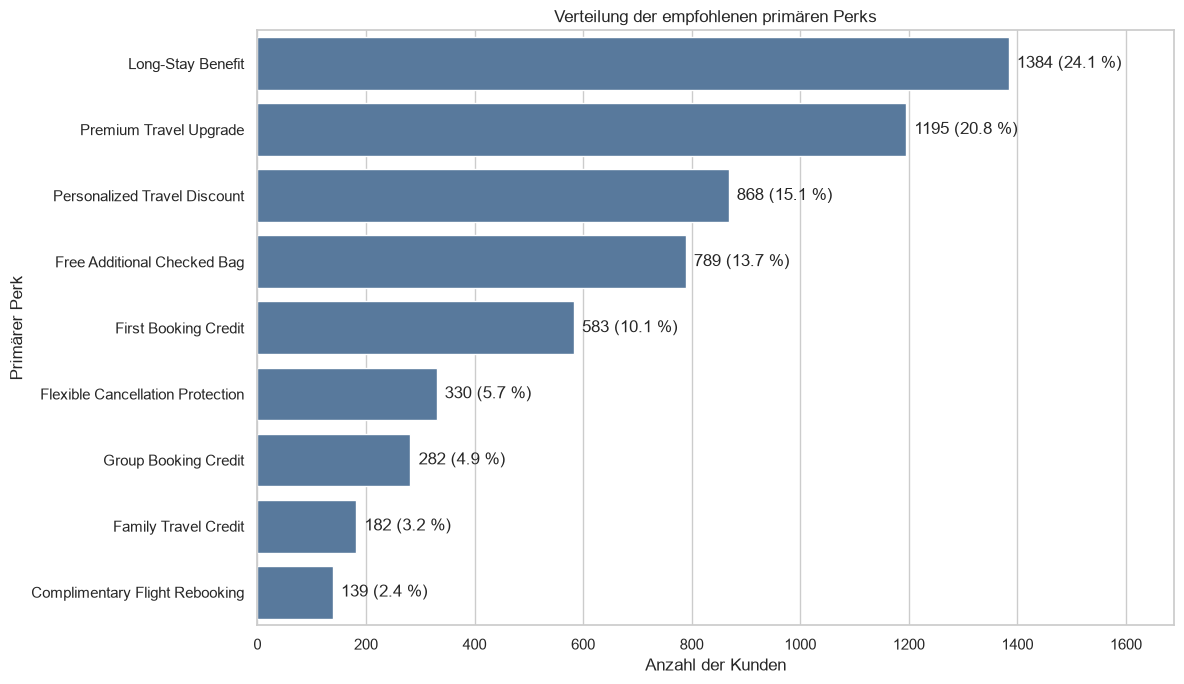

In [20]:
# Verteilung der primären Perks visualisieren.

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 7))


ax = sns.barplot(
    data=perk_distribution,
    x="customer_count",
    y="primary_perk",
    color="#4C78A8"
)


for index, row in perk_distribution.iterrows():

    ax.text(
        row["customer_count"] + 15,
        index,
        (
            f'{row["customer_count"]:.0f} '
            f'({row["customer_share_pct"]:.1f} %)'
        ),
        va="center"
    )


plt.title(
    "Verteilung der empfohlenen primären Perks"
)
plt.xlabel("Anzahl der Kunden")
plt.ylabel("Primärer Perk")

plt.xlim(
    0,
    perk_distribution["customer_count"].max() * 1.22
)

plt.tight_layout()
plt.show()

In [21]:
# Segment-Perk-Zuordnung als Übersicht.

segment_perk_overview = (
    customers_with_perks
    .groupby(
        [
            "final_segment",
            "primary_perk_id",
            "primary_perk",
            "alternative_test_perk_id",
            "alternative_test_perk"
        ],
        as_index=False
    )
    .agg(
        customer_count=("user_id", "nunique")
    )
)


segment_perk_overview["customer_share_pct"] = (
    segment_perk_overview["customer_count"]
    / customers_with_perks["user_id"].nunique()
    * 100
)


segment_perk_overview = (
    segment_perk_overview
    .sort_values(
        "customer_count",
        ascending=False
    )
    .reset_index(drop=True)
)


display(segment_perk_overview)

,final_segment,primary_perk_id,primary_perk,alternative_test_perk_id,alternative_test_perk,customer_count,customer_share_pct
0,Premium Short-Stay Package Travelers,premium_travel_upgrade,Premium Travel Upgrade,personalized_discount,Personalized Travel Discount,987,17.159
1,Discount-Responsive Travelers,personalized_discount,Personalized Travel Discount,first_booking_credit,First Booking Credit,868,15.090
2,Baggage-Intensive Flyers,free_checked_bag,Free Additional Checked Bag,personalized_discount,Personalized Travel Discount,789,13.717
3,Active Longer-Stay Hotel Guests,long_stay_benefit,Long-Stay Benefit,premium_travel_upgrade,Premium Travel Upgrade,647,11.248
4,Low-Conversion Browsers,first_booking_credit,First Booking Credit,personalized_discount,Personalized Travel Discount,583,10.136
5,Long-Stay Hotel Guests,long_stay_benefit,Long-Stay Benefit,personalized_discount,Personalized Travel Discount,558,9.701
6,Cancellation-Experienced Travelers,cancellation_protection,Flexible Cancellation Protection,complimentary_rebooking,Complimentary Flight Rebooking,330,5.737
7,Multi-Person Travelers,group_booking_credit,Group Booking Credit,free_checked_bag,Free Additional Checked Bag,282,4.903
8,High-Value Bookers,premium_travel_upgrade,Premium Travel Upgrade,personalized_discount,Personalized Travel Discount,208,3.616
9,Family Travelers,family_travel_credit,Family Travel Credit,free_checked_bag,Free Additional Checked Bag,182,3.164


In [22]:
# Perk-Verteilung nach Segmentierungsmethode.

perk_by_segmentation_method = (
    customers_with_perks
    .groupby(
        [
            "segmentation_method",
            "primary_perk"
        ],
        as_index=False
    )
    .agg(
        customer_count=("user_id", "nunique")
    )
)


method_totals = (
    customers_with_perks
    .groupby("segmentation_method")["user_id"]
    .nunique()
    .rename("method_customer_count")
    .reset_index()
)


perk_by_segmentation_method = (
    perk_by_segmentation_method
    .merge(
        method_totals,
        on="segmentation_method",
        how="left",
        validate="many_to_one"
    )
)


perk_by_segmentation_method[
    "share_within_method_pct"
] = (
    perk_by_segmentation_method["customer_count"]
    / perk_by_segmentation_method["method_customer_count"]
    * 100
)


display(
    perk_by_segmentation_method.sort_values(
        [
            "segmentation_method",
            "customer_count"
        ],
        ascending=[True, False]
    )
)

,segmentation_method,primary_perk,customer_count,method_customer_count,share_within_method_pct
4,K-Means,Premium Travel Upgrade,987,2817,35.037
3,K-Means,Long-Stay Benefit,826,2817,29.322
1,K-Means,First Booking Credit,583,2817,20.696
2,K-Means,Group Booking Credit,282,2817,10.011
0,K-Means,Complimentary Flight Rebooking,139,2817,4.934
9,Rule-based,Personalized Travel Discount,868,2935,29.574
7,Rule-based,Free Additional Checked Bag,789,2935,26.882
8,Rule-based,Long-Stay Benefit,558,2935,19.012
6,Rule-based,Flexible Cancellation Protection,330,2935,11.244
10,Rule-based,Premium Travel Upgrade,208,2935,7.087


In [23]:
# Abschließende Qualitätsprüfung.

valid_perk_ids = set(
    perk_catalog["perk_id"]
)


perk_quality_check = pd.Series({
    "rows": len(customers_with_perks),

    "unique_users": (
        customers_with_perks["user_id"].nunique()
    ),

    "duplicate_users": (
        customers_with_perks["user_id"]
        .duplicated()
        .sum()
    ),

    "unique_segments": (
        customers_with_perks["final_segment"]
        .nunique()
    ),

    "unique_primary_perks": (
        customers_with_perks["primary_perk_id"]
        .nunique()
    ),

    "missing_segments": (
        customers_with_perks["final_segment"]
        .isna()
        .sum()
    ),

    "missing_primary_perk_ids": (
        customers_with_perks["primary_perk_id"]
        .isna()
        .sum()
    ),

    "missing_primary_perks": (
        customers_with_perks["primary_perk"]
        .isna()
        .sum()
    ),

    "missing_alternative_perk_ids": (
        customers_with_perks[
            "alternative_test_perk_id"
        ]
        .isna()
        .sum()
    ),

    "missing_alternative_perks": (
        customers_with_perks[
            "alternative_test_perk"
        ]
        .isna()
        .sum()
    ),

    "invalid_primary_perk_ids": (
        ~customers_with_perks[
            "primary_perk_id"
        ].isin(valid_perk_ids)
    ).sum(),

    "invalid_alternative_perk_ids": (
        ~customers_with_perks[
            "alternative_test_perk_id"
        ].isin(valid_perk_ids)
    ).sum(),

    "identical_primary_and_alternative": (
        customers_with_perks["primary_perk_id"]
        == customers_with_perks[
            "alternative_test_perk_id"
        ]
    ).sum()
})


display(perk_quality_check)

rows                                 5752
unique_users                         5752
duplicate_users                         0
unique_segments                        12
unique_primary_perks                    9
missing_segments                        0
missing_primary_perk_ids                0
missing_primary_perks                   0
missing_alternative_perk_ids            0
missing_alternative_perks               0
invalid_primary_perk_ids                0
invalid_alternative_perk_ids            0
identical_primary_and_alternative       0
dtype: int64

## 7. Personalisierte Kommunikationsstrategie

Die Perk-Empfehlungen werden nun in segmentspezifische Marketingbotschaften übersetzt. Auch wenn mehrere Segmente denselben grundlegenden Perk erhalten, unterscheiden sich die Ansprache, die Nutzenargumentation und der Call-to-Action entsprechend dem jeweils beobachteten Reiseverhalten.

Die Segmentnamen dienen dabei ausschließlich der internen Steuerung und werden nicht direkt gegenüber den Kunden kommuniziert. Sensible Merkmale wie eine geringe Buchungsrate oder frühere Stornierungen werden in positive Kundenvorteile wie einen Buchungsanreiz, mehr Flexibilität oder zusätzliche Planungssicherheit übersetzt.

Da keine Informationen über bevorzugte Kommunikationskanäle vorliegen, wird noch keine feste Zuordnung zu E-Mail, App-Push oder anderen Kanälen vorgenommen. Die vorgeschlagenen Botschaften stellen Marketinghypothesen dar, deren Wirkung später in kontrollierten Kampagnentests geprüft werden sollte.

In [24]:
# Kommunikationsstrategie definieren.

communication_strategy = pd.DataFrame([
    {
        "final_segment": "Family Travelers",
        "communication_focus": (
            "Familienreisen finanziell und organisatorisch erleichtern"
        ),
        "message_example": (
            "Mehr gemeinsam erleben, weniger zusätzlich bezahlen: "
            "Sichere dir dein persönliches Familien-Reiseguthaben "
            "für eure nächste Reise."
        ),
        "call_to_action": "Familienreise entdecken"
    },
    {
        "final_segment": "Long-Stay Hotel Guests",
        "communication_focus": (
            "Einen finanziellen Mehrwert bei langen Aufenthalten bieten"
        ),
        "message_example": (
            "Länger bleiben lohnt sich: Sichere dir bei deinem nächsten "
            "Langzeitaufenthalt einen exklusiven Preisvorteil oder "
            "eine zusätzliche Hotelnacht."
        ),
        "call_to_action": "Langzeitvorteil entdecken"
    },
    {
        "final_segment": "Baggage-Intensive Flyers",
        "communication_focus": (
            "Mehr Gepäckkomfort bei regelmäßigen Flugreisen bieten"
        ),
        "message_example": (
            "Mehr mitnehmen, entspannter reisen: Bei deiner nächsten "
            "Flugbuchung ist ein zusätzliches Aufgabegepäckstück inklusive."
        ),
        "call_to_action": "Flug mit Gepäck buchen"
    },
    {
        "final_segment": "Discount-Responsive Travelers",
        "communication_focus": (
            "Einen exklusiven und unmittelbar sichtbaren Preisvorteil bieten"
        ),
        "message_example": (
            "Nur für dich: Sichere dir einen persönlichen Rabatt "
            "für deine nächste Reisebuchung."
        ),
        "call_to_action": "Persönlichen Rabatt nutzen"
    },
    {
        "final_segment": "Cancellation-Experienced Travelers",
        "communication_focus": (
            "Planungssicherheit und ein geringeres Buchungsrisiko vermitteln"
        ),
        "message_example": (
            "Plane deine nächste Reise ganz entspannt: Mit deinem "
            "persönlichen Buchungsschutz kannst du innerhalb der "
            "festgelegten Bedingungen kostenfrei stornieren."
        ),
        "call_to_action": "Mit Buchungsschutz planen"
    },
    {
        "final_segment": "High-Value Bookers",
        "communication_focus": (
            "Loyalität mit einem exklusiven Premiumvorteil anerkennen"
        ),
        "message_example": (
            "Danke, dass du regelmäßig mit uns reist: Bei deiner nächsten "
            "Buchung erwartet dich ein exklusiver Premiumvorteil mit "
            "zusätzlichem Komfort und bevorzugtem Service."
        ),
        "call_to_action": "Premiumvorteil entdecken"
    },
    {
        "final_segment": "Low-Conversion Browsers",
        "communication_focus": (
            "Die Hürde zwischen Reisesuche und Buchung reduzieren"
        ),
        "message_example": (
            "Aus Reisesuche wird Vorfreude: Nutze dein persönliches "
            "Startguthaben und buche jetzt deine nächste Reise."
        ),
        "call_to_action": "Startguthaben nutzen"
    },
    {
        "final_segment": "Extended-Stay Hotel Guests",
        "communication_focus": (
            "Das Wohnen auf Zeit durch praktische Zusatzleistungen erleichtern"
        ),
        "message_example": (
            "Mehr Komfort für deinen längeren Aufenthalt: Sichere dir "
            "ein persönliches Extended-Stay-Guthaben für deine Unterkunft "
            "oder zusätzliche Aufenthaltsservices."
        ),
        "call_to_action": "Extended Stay planen"
    },
    {
        "final_segment": "Multi-Person Travelers",
        "communication_focus": (
            "Gemeinsame Reisen für mehrere Personen attraktiver gestalten"
        ),
        "message_example": (
            "Mehr gemeinsam erleben: Sichere dir ein Gruppen-Reiseguthaben "
            "für deine nächste Buchung mit mehreren Reisenden."
        ),
        "call_to_action": "Gemeinsame Reise planen"
    },
    {
        "final_segment": "Flexible One-Way Flyers",
        "communication_focus": (
            "Flexible Reiseplanung bei Flugbuchungen unterstützen"
        ),
        "message_example": (
            "Bleib flexibel: Ändere deinen nächsten Flug einmalig "
            "ohne zusätzliche Umbuchungsgebühr."
        ),
        "call_to_action": "Flexiblen Flug buchen"
    },
    {
        "final_segment": "Active Longer-Stay Hotel Guests",
        "communication_focus": (
            "Regelmäßige und längere Hotelaufenthalte belohnen"
        ),
        "message_example": (
            "Deine längeren Aufenthalte zahlen sich aus: Sichere dir "
            "nach einer festgelegten Anzahl gebuchter Nächte eine "
            "kostenlose Hotelnacht."
        ),
        "call_to_action": "Kostenlose Nacht sichern"
    },
    {
        "final_segment": "Premium Short-Stay Package Travelers",
        "communication_focus": (
            "Kurze Paketaufenthalte durch zusätzlichen Komfort aufwerten"
        ),
        "message_example": (
            "Kurz verreisen, besonders komfortabel ankommen: Freue dich "
            "bei deiner nächsten Paketbuchung auf einen exklusiven "
            "Premiumvorteil wie ein Zimmer-Upgrade oder Late Check-out."
        ),
        "call_to_action": "Premium-Kurzreise entdecken"
    }
])

display(communication_strategy)

,final_segment,communication_focus,message_example,call_to_action
0,Family Travelers,Familienreisen finanziell und organisatorisch ...,"Mehr gemeinsam erleben, weniger zusätzlich bez...",Familienreise entdecken
1,Long-Stay Hotel Guests,Einen finanziellen Mehrwert bei langen Aufenth...,Länger bleiben lohnt sich: Sichere dir bei dei...,Langzeitvorteil entdecken
2,Baggage-Intensive Flyers,Mehr Gepäckkomfort bei regelmäßigen Flugreisen...,"Mehr mitnehmen, entspannter reisen: Bei deiner...",Flug mit Gepäck buchen
3,Discount-Responsive Travelers,Einen exklusiven und unmittelbar sichtbaren Pr...,Nur für dich: Sichere dir einen persönlichen R...,Persönlichen Rabatt nutzen
4,Cancellation-Experienced Travelers,Planungssicherheit und ein geringeres Buchungs...,Plane deine nächste Reise ganz entspannt: Mit ...,Mit Buchungsschutz planen
5,High-Value Bookers,Loyalität mit einem exklusiven Premiumvorteil ...,"Danke, dass du regelmäßig mit uns reist: Bei d...",Premiumvorteil entdecken
6,Low-Conversion Browsers,Die Hürde zwischen Reisesuche und Buchung redu...,Aus Reisesuche wird Vorfreude: Nutze dein pers...,Startguthaben nutzen
7,Extended-Stay Hotel Guests,Das Wohnen auf Zeit durch praktische Zusatzlei...,Mehr Komfort für deinen längeren Aufenthalt: S...,Extended Stay planen
8,Multi-Person Travelers,Gemeinsame Reisen für mehrere Personen attrakt...,Mehr gemeinsam erleben: Sichere dir ein Gruppe...,Gemeinsame Reise planen
9,Flexible One-Way Flyers,Flexible Reiseplanung bei Flugbuchungen unters...,Bleib flexibel: Ändere deinen nächsten Flug ei...,Flexiblen Flug buchen


In [25]:
# Vollständigkeit prüfen.

segments_with_perks = set(
    customers_with_perks["final_segment"]
    .dropna()
    .unique()
)

segments_with_communication = set(
    communication_strategy["final_segment"]
)

print(
    "Segmente ohne Kommunikationsstrategie:",
    sorted(
        segments_with_perks
        - segments_with_communication
    )
)

print(
    "Kommunikationsstrategien ohne vorhandenes Segment:",
    sorted(
        segments_with_communication
        - segments_with_perks
    )
)

print(
    "Doppelte Kommunikationsstrategien:",
    communication_strategy["final_segment"]
    .duplicated()
    .sum()
)

Segmente ohne Kommunikationsstrategie: []
Kommunikationsstrategien ohne vorhandenes Segment: []
Doppelte Kommunikationsstrategien: 0


In [26]:
# Kommunikationsstrategie den Kunden zuordnen.

customers_with_perks = customers_with_perks.merge(
    communication_strategy,
    on="final_segment",
    how="left",
    validate="many_to_one"
)

print("Zeilen:", len(customers_with_perks))

print(
    "Eindeutige Nutzer:",
    customers_with_perks["user_id"].nunique()
)

print(
    "Fehlende Nachrichten:",
    customers_with_perks["message_example"]
    .isna()
    .sum()
)

print(
    "Fehlende Call-to-Actions:",
    customers_with_perks["call_to_action"]
    .isna()
    .sum()
)

Zeilen: 5752
Eindeutige Nutzer: 5752
Fehlende Nachrichten: 0
Fehlende Call-to-Actions: 0


In [27]:
# Finale Strategieübersicht erstellen.

final_strategy_overview = (
    customers_with_perks
    .groupby(
        [
            "final_segment",
            "primary_perk",
            "alternative_test_perk",
            "communication_focus",
            "message_example",
            "call_to_action",
            "success_kpi",
            "guardrail"
        ],
        as_index=False,
        observed=True
    )
    .agg(
        customer_count=("user_id", "nunique")
    )
)

final_strategy_overview["customer_share_pct"] = (
    final_strategy_overview["customer_count"]
    / customers_with_perks["user_id"].nunique()
    * 100
)

final_strategy_overview["customer_share_pct"] = (
    final_strategy_overview["customer_share_pct"]
    .round(1)
)

final_strategy_overview = (
    final_strategy_overview
    .sort_values(
        "customer_count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_strategy_overview)

,final_segment,primary_perk,alternative_test_perk,communication_focus,message_example,call_to_action,success_kpi,guardrail,customer_count,customer_share_pct
0,Premium Short-Stay Package Travelers,Premium Travel Upgrade,Personalized Travel Discount,Kurze Paketaufenthalte durch zusätzlichen Komf...,"Kurz verreisen, besonders komfortabel ankommen...",Premium-Kurzreise entdecken,Wiederholte Paketbuchungsrate und Einlösungsqu...,Kosten und Verfügbarkeit der Premiumleistungen,987,17.200
1,Discount-Responsive Travelers,Personalized Travel Discount,First Booking Credit,Einen exklusiven und unmittelbar sichtbaren Pr...,Nur für dich: Sichere dir einen persönlichen R...,Persönlichen Rabatt nutzen,Inkrementelle Buchungsrate nach Rabattangebot,Deckungsbeitrag nach Rabatt und Kosten pro zus...,868,15.100
2,Baggage-Intensive Flyers,Free Additional Checked Bag,Personalized Travel Discount,Mehr Gepäckkomfort bei regelmäßigen Flugreisen...,"Mehr mitnehmen, entspannter reisen: Bei deiner...",Flug mit Gepäck buchen,Flug-Wiederbuchungsrate und Einlösungsquote de...,Gepäckkosten pro inkrementeller Flugbuchung,789,13.700
3,Active Longer-Stay Hotel Guests,Long-Stay Benefit,Premium Travel Upgrade,Regelmäßige und längere Hotelaufenthalte belohnen,Deine längeren Aufenthalte zahlen sich aus: Si...,Kostenlose Nacht sichern,Hotel-Wiederbuchungsrate und gebuchte Hotelnächte,Kosten der kostenlosen Nacht pro inkrementelle...,647,11.200
4,Low-Conversion Browsers,First Booking Credit,Personalized Travel Discount,Die Hürde zwischen Reisesuche und Buchung redu...,Aus Reisesuche wird Vorfreude: Nutze dein pers...,Startguthaben nutzen,Conversion von der Suche zur Buchung,Anreizkosten pro inkrementeller Buchung,583,10.100
5,Long-Stay Hotel Guests,Long-Stay Benefit,Personalized Travel Discount,Einen finanziellen Mehrwert bei langen Aufenth...,Länger bleiben lohnt sich: Sichere dir bei dei...,Langzeitvorteil entdecken,Wiederbuchungsrate und gebuchte Hotelnächte,Perk-Kosten pro zusätzlicher Hotelnacht,558,9.700
6,Cancellation-Experienced Travelers,Flexible Cancellation Protection,Complimentary Flight Rebooking,Planungssicherheit und ein geringeres Buchungs...,Plane deine nächste Reise ganz entspannt: Mit ...,Mit Buchungsschutz planen,Erneute Buchungsrate nach Angebot des Flexibil...,"Stornierungsquote, Erstattungswert und entgang...",330,5.700
7,Multi-Person Travelers,Group Booking Credit,Free Additional Checked Bag,Gemeinsame Reisen für mehrere Personen attrakt...,Mehr gemeinsam erleben: Sichere dir ein Gruppe...,Gemeinsame Reise planen,Buchungsrate von Reisen mit mehreren Personen,Guthabenkosten pro inkrementeller Gruppenbuchung,282,4.900
8,High-Value Bookers,Premium Travel Upgrade,Personalized Travel Discount,Loyalität mit einem exklusiven Premiumvorteil ...,"Danke, dass du regelmäßig mit uns reist: Bei d...",Premiumvorteil entdecken,Wiederbuchungsrate und Entwicklung des Kundenw...,Kosten des Premiumvorteils im Verhältnis zum z...,208,3.600
9,Family Travelers,Family Travel Credit,Free Additional Checked Bag,Familienreisen finanziell und organisatorisch ...,"Mehr gemeinsam erleben, weniger zusätzlich bez...",Familienreise entdecken,Buchungs- und Wiederbuchungsrate von Familienr...,Guthabenkosten pro inkrementeller Buchung,182,3.200


### Zwischenfazit zur Kommunikationsstrategie

Für alle zwölf Kundensegmente wurde eine eigene Nutzenargumentation mit passender Beispielbotschaft und einem eindeutigen Call-to-Action entwickelt. Auch bei gemeinsam genutzten Perks bleibt die Ansprache dadurch auf das charakteristische Verhalten und den vermuteten Bedarf des jeweiligen Segments ausgerichtet.

Die Segmentnamen werden ausschließlich intern verwendet. Sensible Verhaltensmerkmale wie geringe Buchungsaktivität, frühere Stornierungen oder ein besonders hoher Kundenwert werden nicht ausdrücklich genannt, sondern in positive Vorteile wie einen Buchungsanreiz, mehr Flexibilität oder zusätzlichen Komfort übersetzt.

Die Kommunikationsvorschläge stellen zunächst datenbasierte Marketinghypothesen dar. Der primäre Perk sollte je Segment gegen die festgelegte alternative Testvariante geprüft werden. Neben der Wirkung auf die jeweilige Erfolgskennzahl müssen dabei auch die definierten Kostengrenzen berücksichtigt werden.

## 8. Test- und Erfolgsmessung

Die bisherige Perk-Zuweisung basiert auf beobachtetem Kundenverhalten und stellt
daher eine begründete Empfehlung, aber noch keinen Nachweis ihrer tatsächlichen
Wirkung dar. Um zu prüfen, ob die empfohlenen Vorteile zusätzliche Buchungen
auslösen, sollte innerhalb jedes Kundensegments ein kontrollierter Kampagnentest
durchgeführt werden.

Dabei werden die Kunden zufällig auf drei Testgruppen verteilt:

- **Kontrollgruppe:** erhält die reguläre Kommunikation ohne zusätzlichen Perk,
- **Primärgruppe:** erhält den für das Segment empfohlenen primären Perk,
- **Alternativgruppe:** erhält den zuvor definierten alternativen Test-Perk.

Durch die zufällige Verteilung innerhalb der Segmente können Unterschiede in der
späteren Buchungsaktivität besser auf die jeweilige Maßnahme zurückgeführt
werden. Vor einer realen Kampagne sollten zusätzlich die benötigte
Stichprobengröße, die Testdauer und die wirtschaftlich vertretbaren Perk-Kosten
festgelegt werden.

In [28]:
# Testkonzept dokumentieren.
 
test_plan = (
    perk_assignment[
        [
            "final_segment",
            "primary_perk",
            "alternative_test_perk",
            "success_kpi",
            "guardrail"
        ]
    ]
    .copy()
)

test_plan["control_group"] = (
    "Reguläre Kommunikation ohne zusätzlichen Perk"
)

test_plan["test_design"] = (
    "Randomisierter Drei-Gruppen-Test innerhalb des Segments"
)

display(test_plan)

,final_segment,primary_perk,alternative_test_perk,success_kpi,guardrail,control_group,test_design
0,Family Travelers,Family Travel Credit,Free Additional Checked Bag,Buchungs- und Wiederbuchungsrate von Familienr...,Guthabenkosten pro inkrementeller Buchung,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
1,Multi-Person Travelers,Group Booking Credit,Free Additional Checked Bag,Buchungsrate von Reisen mit mehreren Personen,Guthabenkosten pro inkrementeller Gruppenbuchung,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
2,Baggage-Intensive Flyers,Free Additional Checked Bag,Personalized Travel Discount,Flug-Wiederbuchungsrate und Einlösungsquote de...,Gepäckkosten pro inkrementeller Flugbuchung,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
3,Flexible One-Way Flyers,Complimentary Flight Rebooking,Personalized Travel Discount,Flug-Wiederbuchungsrate und Nutzung der Umbuch...,Umbuchungshäufigkeit und ungedeckte Tarifdiffe...,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
4,Cancellation-Experienced Travelers,Flexible Cancellation Protection,Complimentary Flight Rebooking,Erneute Buchungsrate nach Angebot des Flexibil...,"Stornierungsquote, Erstattungswert und entgang...",Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
5,Discount-Responsive Travelers,Personalized Travel Discount,First Booking Credit,Inkrementelle Buchungsrate nach Rabattangebot,Deckungsbeitrag nach Rabatt und Kosten pro zus...,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
6,Low-Conversion Browsers,First Booking Credit,Personalized Travel Discount,Conversion von der Suche zur Buchung,Anreizkosten pro inkrementeller Buchung,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
7,High-Value Bookers,Premium Travel Upgrade,Personalized Travel Discount,Wiederbuchungsrate und Entwicklung des Kundenw...,Kosten des Premiumvorteils im Verhältnis zum z...,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
8,Long-Stay Hotel Guests,Long-Stay Benefit,Personalized Travel Discount,Wiederbuchungsrate und gebuchte Hotelnächte,Perk-Kosten pro zusätzlicher Hotelnacht,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...
9,Extended-Stay Hotel Guests,Long-Stay Benefit,Premium Travel Upgrade,Wiederbuchungsrate von Extended-Stay-Unterkünften,Guthabenkosten und Verfügbarkeit der Partnerle...,Reguläre Kommunikation ohne zusätzlichen Perk,Randomisierter Drei-Gruppen-Test innerhalb des...


In [29]:
# Kunden zufällig auf die Testgruppen verteilen.

import numpy as np

customers_with_perks["experiment_group"] = pd.NA

rng = np.random.default_rng(42)

for segment in customers_with_perks["final_segment"].dropna().unique():
    
    segment_indices = customers_with_perks.index[
        customers_with_perks["final_segment"] == segment
    ].to_numpy()
    
    shuffled_indices = rng.permutation(segment_indices)
    
    control_indices, primary_indices, alternative_indices = (
        np.array_split(shuffled_indices, 3)
    )
    
    customers_with_perks.loc[
        control_indices,
        "experiment_group"
    ] = "Control"
    
    customers_with_perks.loc[
        primary_indices,
        "experiment_group"
    ] = "Primary perk"
    
    customers_with_perks.loc[
        alternative_indices,
        "experiment_group"
    ] = "Alternative perk"


In [30]:
# Tatsächlich auszuspielendes Angebot festlegen.

customers_with_perks["assigned_test_offer"] = np.select(
    [
        customers_with_perks["experiment_group"].eq("Control"),
        customers_with_perks["experiment_group"].eq("Primary perk"),
        customers_with_perks["experiment_group"].eq("Alternative perk")
    ],
    [
        "No additional perk",
        customers_with_perks["primary_perk"],
        customers_with_perks["alternative_test_perk"]
    ],
    default=pd.NA
)

In [31]:
# Konkrete Ausgestaltung des tatsächlich zugewiesenen Testangebots festlegen.

customers_with_perks[
    "assigned_test_offer_configuration"
] = np.select(
    [
        customers_with_perks[
            "experiment_group"
        ].eq("Control"),

        customers_with_perks[
            "experiment_group"
        ].eq("Primary perk"),

        customers_with_perks[
            "experiment_group"
        ].eq("Alternative perk")
    ],
    [
        "No additional perk",

        customers_with_perks[
            "primary_perk_configuration"
        ],

        customers_with_perks[
            "alternative_test_configuration"
        ]
    ],
    default=pd.NA
)

In [32]:
# Größe der Testgruppen überprüfen.

experiment_group_overview = (
    customers_with_perks
    .groupby(
        ["final_segment", "experiment_group"],
        as_index=False
    )
    .agg(
        customer_count=("user_id", "nunique")
    )
)

experiment_group_overview["segment_total"] = (
    experiment_group_overview
    .groupby("final_segment")["customer_count"]
    .transform("sum")
)

experiment_group_overview["group_share_pct"] = (
    experiment_group_overview["customer_count"]
    / experiment_group_overview["segment_total"]
    * 100
)

display(
    experiment_group_overview.sort_values(
        ["final_segment", "experiment_group"]
    )
)

,final_segment,experiment_group,customer_count,segment_total,group_share_pct
0,Active Longer-Stay Hotel Guests,Alternative perk,215,647,33.230
1,Active Longer-Stay Hotel Guests,Control,216,647,33.385
2,Active Longer-Stay Hotel Guests,Primary perk,216,647,33.385
3,Baggage-Intensive Flyers,Alternative perk,263,789,33.333
4,Baggage-Intensive Flyers,Control,263,789,33.333
5,Baggage-Intensive Flyers,Primary perk,263,789,33.333
6,Cancellation-Experienced Travelers,Alternative perk,110,330,33.333
7,Cancellation-Experienced Travelers,Control,110,330,33.333
8,Cancellation-Experienced Travelers,Primary perk,110,330,33.333
9,Discount-Responsive Travelers,Alternative perk,289,868,33.295


In [33]:
# Qualitätsprüfung der Testzuweisung.

experiment_quality_check = pd.Series({
    "rows": len(customers_with_perks),
    "unique_users": customers_with_perks["user_id"].nunique(),
    "duplicate_users": customers_with_perks["user_id"].duplicated().sum(),
    "missing_experiment_groups": (
        customers_with_perks["experiment_group"].isna().sum()
    ),
    "missing_test_offers": (
        customers_with_perks["assigned_test_offer"].isna().sum()
    ),
    "number_of_test_groups": (
        customers_with_perks["experiment_group"].nunique()
    )
})

display(experiment_quality_check)

rows                         5752
unique_users                 5752
duplicate_users                 0
missing_experiment_groups       0
missing_test_offers             0
number_of_test_groups           3
dtype: int64

### Vorbereitung der späteren Erfolgsmessung

Nach Durchführung der Kampagne müssten neue Ergebnisvariablen ergänzt werden, beispielsweise:

- campaign_delivered: Kampagne erfolgreich zugestellt,
- campaign_opened: Nachricht geöffnet,
- perk_redeemed: Perk eingelöst,
- booking_after_campaign: Buchung nach Kampagnenkontakt,
- revenue_after_campaign_usd: danach erzielter Umsatz,
- perk_cost_usd: verursachte Perk-Kosten.

### Zwischenfazit zum Testkonzept

Die segmentbasierten Perk-Empfehlungen sollten vor einer dauerhaften Einführung
in einem randomisierten Kampagnentest überprüft werden. Dafür werden die Kunden
innerhalb jedes Segments einer Kontrollgruppe, der primären Perk-Variante oder
einer alternativen Perk-Variante zugeordnet.

Als Hauptkennzahl wird jeweils die zuvor definierte Buchungs- oder
Conversion-Kennzahl verwendet. Ergänzend werden Kosten, Deckungsbeitrag,
Stornierungen und weitere segmentspezifische Kontrollkennzahlen berücksichtigt.
Dadurch wird nicht nur geprüft, ob ein Perk wirkt, sondern auch, ob sein Einsatz
wirtschaftlich sinnvoll ist.

Da einige Segmente vergleichsweise klein sind, sollte vor dem tatsächlichen
Kampagnenstart eine statistische Fallzahlplanung erfolgen. Die aktuelle
Dreiteilung stellt daher zunächst ein methodisches Testkonzept dar und noch
keinen abschließend dimensionierten Versuchsplan.

## 9. Gesamtfazit und Handlungsempfehlungen

Ziel dieses Notebooks war es, die zuvor entwickelten Kundensegmente in konkrete Empfehlungen für ein personalisiertes Rewards-Programm zu übersetzen. Dafür wurden neun operativ steuerbare Perk-Familien definiert und den zwölf Kundensegmenten anhand ihres beobachteten Reise-, Buchungs-, Rabatt- und Stornierungsverhaltens zugeordnet.

Die ursprünglich vorgeschlagenen Benefits wurden dabei nicht unverändert übernommen, sondern anhand der identifizierten Kundenbedürfnisse weiterentwickelt. Dadurch konnten beispielsweise Familien- und Gruppenreisen, längere Aufenthalte, flexible Flugreisen und besonders wertvolle Kunden differenzierter berücksichtigt werden.

### Zentrale Ergebnisse

Für jedes Kundensegment wurde eine primäre Perk-Familie mit einer segmentspezifischen Ausgestaltung bestimmt:

- **Family Travelers:** Family Travel Credit
- **Multi-Person Travelers:** Group Booking Credit
- **Baggage-Intensive Flyers:** Free Additional Checked Bag
- **Flexible One-Way Flyers:** Complimentary Flight Rebooking
- **Cancellation-Experienced Travelers:** Flexible Cancellation Protection
- **Discount-Responsive Travelers:** Personalized Travel Discount
- **Low-Conversion Browsers:** First Booking Credit
- **High-Value Bookers:** Premium Travel Upgrade
- **Long-Stay Hotel Guests:** Long-Stay Benefit
- **Extended-Stay Hotel Guests:** Long-Stay Benefit
- **Active Longer-Stay Hotel Guests:** Long-Stay Benefit
- **Premium Short-Stay Package Travelers:** Premium Travel Upgrade

Die Anzahl der Segmente entspricht bewusst nicht der Anzahl der Perk-Familien. Mehrere Segmente können ein ähnliches Grundbedürfnis besitzen, aber eine unterschiedliche konkrete Ausgestaltung des Benefits erhalten.

So wird der **Long-Stay Benefit** bei besonders langen Aufenthalten beispielsweise als Langzeitrabatt oder kostenlose Nacht, bei Extended-Stay-Gästen als Guthaben für Unterkunft oder zusätzliche Services und bei besonders aktiven Hotelgästen als Belohnung für wiederholt gebuchte Nächte ausgestaltet.

Auch der **Premium Travel Upgrade** unterscheidet sich je nach Segment. Für besonders wertvolle Kunden kann er bevorzugten Service, Reiseguthaben oder ein Upgrade umfassen, während bei kurzen Premium-Paketaufenthalten vor allem Zimmer-Upgrades, Flughafentransfers oder Late Check-out relevant sind.

Durch dieses Vorgehen bleibt das Rewards-Programm mit neun Perk-Familien operativ überschaubar, während Nutzenargumentation, konkrete Ausgestaltung, Botschaft und Call-to-Action weiterhin auf das jeweilige Kundensegment zugeschnitten werden.

### Interpretation der Empfehlungen

Die Zuweisungen basieren auf nachvollziehbaren Verbindungen zwischen dem beobachteten Kundenverhalten und dem vermuteten Nutzen eines Vorteils. Kunden mit einer hohen Aufgabegepäcknutzung erhalten beispielsweise einen Gepäckvorteil, während Kunden mit früheren Stornierungen durch einen begrenzten Stornierungsschutz angesprochen werden.

Für Kunden mit geringer Buchungsaktivität wird die Einstiegshürde durch ein einmaliges Buchungsguthaben reduziert. Längere Hotelaufenthalte werden durch einen Long-Stay Benefit belohnt, während höherwertige oder besonders aktive Kunden zusätzliche Komfort- und Premiumleistungen erhalten.

Die Empfehlungen stellen jedoch begründete Marketinghypothesen und keine nachgewiesenen individuellen Kundenpräferenzen dar. Aus den historischen Daten kann nicht sicher abgeleitet werden, dass ein empfohlener Perk tatsächlich zusätzliche Buchungen verursacht.

Zudem enthält der Datensatz keine vollständigen Informationen über Deckungsbeiträge, Partnerkonditionen oder die realen Kosten einzelner Leistungen. Die genaue Höhe der Guthaben, Rabatte und Einlösegrenzen kann daher erst nach einer wirtschaftlichen Prüfung festgelegt werden.

### Empfohlenes weiteres Vorgehen

Vor einer dauerhaften Einführung sollte TravelTide die Empfehlungen in kontrollierten Kampagnentests überprüfen. Innerhalb jedes Segments können dabei drei Gruppen miteinander verglichen werden:

1. eine Kontrollgruppe ohne zusätzlichen Perk,
2. eine Gruppe mit dem empfohlenen primären Perk,
3. eine Gruppe mit der alternativen Testvariante.

Als Erfolgskennzahlen sollten insbesondere Buchungs- und Wiederbuchungsraten, Conversion-Raten, Perk-Einlösungen und zusätzlicher Umsatz betrachtet werden. Gleichzeitig müssen Perk-Kosten, Deckungsbeiträge, Stornierungen und weitere segmentspezifische Kontrollkennzahlen überwacht werden.

Da einige Segmente vergleichsweise klein sind, sollte vor dem Kampagnenstart eine statistische Fallzahlplanung durchgeführt werden. Falls die vorhandene Kundenzahl für drei ausreichend große Testgruppen nicht ausreicht, können zunächst nur Kontrollgruppe und primäre Perk-Gruppe verglichen oder ähnliche Segmente für einzelne Tests zusammengefasst werden.

Die in diesem Notebook vorgenommene experimentelle Gruppenzuweisung stellt daher ein methodisches Testkonzept und noch keinen abschließend dimensionierten Kampagnenplan dar.

### Abschließende Bewertung

Die entwickelte Strategie verbindet die datenbasierte Kundensegmentierung mit konkreten und steuerbaren Marketingmaßnahmen. Jeder Kunde verfügt nun über ein finales Segment, eine primäre Perk-Empfehlung, eine konkrete Ausgestaltung, eine alternative Testvariante, eine passende Kommunikationsidee sowie relevante Erfolgs- und Kontrollkennzahlen.

Damit steht TravelTide eine konsistente Grundlage für die Einführung eines personalisierten Rewards-Programms zur Verfügung. Die Empfehlungen sollten als Ausgangspunkt eines lernenden Systems verstanden werden: Zukünftige Kampagnenergebnisse können genutzt werden, um die Perk-Zuweisungen, Ausgestaltungen und Kommunikationsansätze schrittweise zu überprüfen, wirtschaftlich zu bewerten und weiterzuentwickeln.

## 10. Export der finalen Ergebnisse

Zum Abschluss werden die entwickelten Perk-Empfehlungen und
Kommunikationsstrategien gespeichert. Die finale Kundentabelle enthält neben
den ursprünglichen Kundenmerkmalen und Segmentinformationen auch den primären
Perk, die alternative Testvariante, die vorgeschlagene Kundenansprache sowie
die experimentelle Gruppenzuweisung.

Zusätzlich wird eine kompakte Strategieübersicht auf Segmentebene exportiert.
Sie fasst Segmentgröße, Perk-Empfehlung, Kommunikationsstrategie,
Erfolgskennzahl und Kontrollkennzahl zusammen.

In [34]:
# Finale Exportspalten prüfen.# Finale Exportspalten prüfen.

recommendation_columns = [
    # Kunden- und Segmentinformationen
    "user_id",
    "final_segment",
    "segmentation_method",

    # Primäre Perk-Empfehlung
    "primary_perk_id",
    "primary_perk",
    "primary_perk_configuration",

    # Alternative Testvariante
    "alternative_test_perk_id",
    "alternative_test_perk",
    "alternative_test_configuration",

    # Begründung der Empfehlung
    "segment_need",
    "decision_basis",
    "recommendation_reason",

    # Kommunikationsstrategie
    "communication_focus",
    "message_example",
    "call_to_action",

    # Erfolgsmessung
    "success_kpi",
    "guardrail",

    # Experimentelle Zuweisung
    "experiment_group",
    "assigned_test_offer",
    "assigned_test_offer_configuration"
]


missing_recommendation_columns = [
    column
    for column in recommendation_columns
    if column not in customers_with_perks.columns
]


print(
    "Fehlende Empfehlungsspalten:",
    missing_recommendation_columns
)

Fehlende Empfehlungsspalten: []


In [35]:
# Finale Qualitätsprüfung.

final_export_check = pd.Series({
    "rows": len(customers_with_perks),
    "unique_users": customers_with_perks["user_id"].nunique(),
    "duplicate_users": customers_with_perks["user_id"].duplicated().sum(),
    "missing_final_segments": (
        customers_with_perks["final_segment"].isna().sum()
    ),
    "missing_primary_perks": (
        customers_with_perks["primary_perk"].isna().sum()
    ),
    "missing_messages": (
        customers_with_perks["message_example"].isna().sum()
    ),
    "missing_experiment_groups": (
        customers_with_perks["experiment_group"].isna().sum()
    ),
    "missing_test_offers": (
        customers_with_perks["assigned_test_offer"].isna().sum()
    ),
    "missing_test_offer_configurations": (
    customers_with_perks["assigned_test_offer_configuration"].isna().sum()
)
})


display(final_export_check)

rows                                 5752
unique_users                         5752
duplicate_users                         0
missing_final_segments                  0
missing_primary_perks                   0
missing_messages                        0
missing_experiment_groups               0
missing_test_offers                     0
missing_test_offer_configurations       0
dtype: int64

In [36]:
# Exportverzeichnis anlegen.
 
from pathlib import Path

output_directory = Path("../data/finalized")
output_directory.mkdir(
    parents=True,
    exist_ok=True
)

In [37]:
# Finale Kundentabelle exportieren.

customer_export_path = (
    output_directory
    / "traveltide_customer_perk_recommendations.csv"
)

customers_with_perks.to_csv(
    customer_export_path,
    index=False
)

print(
    "Finale Kundentabelle gespeichert unter:",
    customer_export_path
)

Finale Kundentabelle gespeichert unter: ..\data\finalized\traveltide_customer_perk_recommendations.csv


In [38]:
# Strategieübersicht exportieren.

strategy_export_path = (
    output_directory
    / "traveltide_segment_perk_strategy.csv"
)

final_strategy_overview.to_csv(
    strategy_export_path,
    index=False
)

print(
    "Strategieübersicht gespeichert unter:",
    strategy_export_path
)

Strategieübersicht gespeichert unter: ..\data\finalized\traveltide_segment_perk_strategy.csv


In [39]:
# Perk-Katalog und Testplan exportieren.

perk_catalog_export_path = (
    output_directory
    / "traveltide_perk_catalog.csv"
)

test_plan_export_path = (
    output_directory
    / "traveltide_perk_test_plan.csv"
)

perk_catalog.to_csv(
    perk_catalog_export_path,
    index=False
)

test_plan.to_csv(
    test_plan_export_path,
    index=False
)

print(
    "Perk-Katalog gespeichert unter:",
    perk_catalog_export_path
)

print(
    "Testplan gespeichert unter:",
    test_plan_export_path
)

Perk-Katalog gespeichert unter: ..\data\finalized\traveltide_perk_catalog.csv
Testplan gespeichert unter: ..\data\finalized\traveltide_perk_test_plan.csv


In [40]:
# Exportierte Dateien kontrollieren.

exported_files = [
    customer_export_path,
    strategy_export_path,
    perk_catalog_export_path,
    test_plan_export_path
]

for file_path in exported_files:
    print(
        file_path.name,
        "| vorhanden:",
        file_path.exists(),
        "| Dateigröße:",
        file_path.stat().st_size,
        "Bytes"
    )

traveltide_customer_perk_recommendations.csv | vorhanden: True | Dateigröße: 8778163 Bytes
traveltide_segment_perk_strategy.csv | vorhanden: True | Dateigröße: 5053 Bytes
traveltide_perk_catalog.csv | vorhanden: True | Dateigröße: 2307 Bytes
traveltide_perk_test_plan.csv | vorhanden: True | Dateigröße: 3535 Bytes


In [41]:
# Export überprüfen.
 
export_check = pd.read_csv(
    customer_export_path
)

print("Exportierte Zeilen:", len(export_check))
print(
    "Exportierte Nutzer:",
    export_check["user_id"].nunique()
)
print(
    "Exportierte Spalten:",
    export_check.shape[1]
)

display(
    export_check[
        recommendation_columns
    ].head()
)

Exportierte Zeilen: 5752
Exportierte Nutzer: 5752
Exportierte Spalten: 111


,user_id,final_segment,segmentation_method,primary_perk_id,primary_perk,primary_perk_configuration,alternative_test_perk_id,alternative_test_perk,alternative_test_configuration,segment_need,decision_basis,recommendation_reason,communication_focus,message_example,call_to_action,success_kpi,guardrail,experiment_group,assigned_test_offer,assigned_test_offer_configuration
0,23557,Long-Stay Hotel Guests,Rule-based,long_stay_benefit,Long-Stay Benefit,Gestaffelter Langzeitrabatt oder eine kostenlo...,personalized_discount,Personalized Travel Discount,Zimmer-Upgrade oder Late Check-out nach Verfüg...,Finanzieller Mehrwert bei besonders langen Auf...,Besonders hohe durchschnittliche Aufenthaltsdauer,Dieses Segment weist die längsten Hotelaufenth...,Einen finanziellen Mehrwert bei langen Aufenth...,Länger bleiben lohnt sich: Sichere dir bei dei...,Langzeitvorteil entdecken,Wiederbuchungsrate und gebuchte Hotelnächte,Perk-Kosten pro zusätzlicher Hotelnacht,Control,No additional perk,No additional perk
1,94883,Multi-Person Travelers,K-Means,group_booking_credit,Group Booking Credit,Reiseguthaben ab einer definierten Anzahl geme...,free_checked_bag,Free Additional Checked Bag,Ein zusätzliches kostenloses Aufgabegepäckstüc...,Kostenersparnis bei Reisen mit mehreren Personen,Regelmäßige Buchungen für mehrere gemeinsam Re...,Dieses Segment bucht regelmäßig Reisen für meh...,Gemeinsame Reisen für mehrere Personen attrakt...,Mehr gemeinsam erleben: Sichere dir ein Gruppe...,Gemeinsame Reise planen,Buchungsrate von Reisen mit mehreren Personen,Guthabenkosten pro inkrementeller Gruppenbuchung,Primary perk,Group Booking Credit,Reiseguthaben ab einer definierten Anzahl geme...
2,101486,Active Longer-Stay Hotel Guests,K-Means,long_stay_benefit,Long-Stay Benefit,Eine kostenlose Nacht nach einer festgelegten ...,premium_travel_upgrade,Premium Travel Upgrade,Zimmer-Upgrade oder zusätzlicher Aufenthaltsse...,Belohnung regelmäßiger und längerer Hotelaufen...,Hohe Hotelaktivität und vergleichsweise lange ...,Dieses Segment verbindet eine hohe Hotelaktivi...,Regelmäßige und längere Hotelaufenthalte belohnen,Deine längeren Aufenthalte zahlen sich aus: Si...,Kostenlose Nacht sichern,Hotel-Wiederbuchungsrate und gebuchte Hotelnächte,Kosten der kostenlosen Nacht pro inkrementelle...,Primary perk,Long-Stay Benefit,Eine kostenlose Nacht nach einer festgelegten ...
3,101961,Active Longer-Stay Hotel Guests,K-Means,long_stay_benefit,Long-Stay Benefit,Eine kostenlose Nacht nach einer festgelegten ...,premium_travel_upgrade,Premium Travel Upgrade,Zimmer-Upgrade oder zusätzlicher Aufenthaltsse...,Belohnung regelmäßiger und längerer Hotelaufen...,Hohe Hotelaktivität und vergleichsweise lange ...,Dieses Segment verbindet eine hohe Hotelaktivi...,Regelmäßige und längere Hotelaufenthalte belohnen,Deine längeren Aufenthalte zahlen sich aus: Si...,Kostenlose Nacht sichern,Hotel-Wiederbuchungsrate und gebuchte Hotelnächte,Kosten der kostenlosen Nacht pro inkrementelle...,Control,No additional perk,No additional perk
4,106907,Family Travelers,Rule-based,family_travel_credit,Family Travel Credit,"Reiseguthaben für Familienzimmer, Sitzplatzres...",free_checked_bag,Free Additional Checked Bag,Ein zusätzliches kostenloses Aufgabegepäckstück,Finanzielle Entlastung und weniger Zusatzkoste...,Reisen mit Kindern und mehreren gemeinsam gebu...,Das Segment reist mit Kindern und mehreren gem...,Familienreisen finanziell und organisatorisch ...,"Mehr gemeinsam erleben, weniger zusätzlich bez...",Familienreise entdecken,Buchungs- und Wiederbuchungsrate von Familienr...,Guthabenkosten pro inkrementeller Buchung,Alternative perk,Free Additional Checked Bag,Ein zusätzliches kostenloses Aufgabegepäckstück


### Abschluss

Die Segment- und Perk-Strategie wurde erfolgreich auf Kundenebene
zusammengeführt und exportiert. Neben der vollständigen Kundentabelle stehen
separate Übersichten für die strategische Perk-Zuweisung, den Perk-Katalog und
das vorgeschlagene Testkonzept zur Verfügung.

Damit ist die analytische Grundlage für die segmentbasierte Ansprache und die
spätere experimentelle Überprüfung des TravelTide-Rewards-Programms
vollständig vorbereitet.